# Homework 3

Daniel Ott (33551440), Samuel Šmíd (73123255), Anna Turnerová (70701808)

For the econometric analysis, we use the datasets from the folder 70701808

## Packages

In [56]:
library(fst)
library(highfrequency)
library(xts)
library(rugarch)

Warning message:
"package 'rugarch' was built under R version 4.5.2"
Loading required package: parallel



## Data import

In [5]:
dates<-read.csv("students_HW3/70701808_periods_HW_3.csv")
msft<-read.fst("HW_3_data/HW_3_MSFT_1min.fst")
bac<-read.fst("HW_3_data/HW_3_BAC_1min.fst")
xom<-read.fst("HW_3_data/HW_3_XOM_1min.fst")

Warning message:
"package 'fstcore' was built under R version 4.5.3"


In [6]:
head(dates)

,X,Ticker,Start,End
,<int>,<chr>,<int>,<int>
1,1,MSFT,2011,2016
2,2,BAC,2012,2016
3,3,XOM,2015,2016


In [7]:
print(dim(msft))
head(msft)

[1] 933337      2


,index,V1
,<dttm>,<dbl>
1,2010-01-04 07:44:00,24.6994
2,2010-01-04 07:56:00,24.6673
3,2010-01-04 08:00:00,24.6593
4,2010-01-04 08:01:00,24.6272
5,2010-01-04 08:05:00,24.6192
6,2010-01-04 08:06:00,24.6192


In [8]:
print(dim(bac))
head(bac)

[1] 1134050       2


,index,V1
,<dttm>,<dbl>
1,2010-01-04 07:00:00,14.0864
2,2010-01-04 07:04:00,14.0864
3,2010-01-04 07:06:00,14.0679
4,2010-01-04 07:08:00,14.0586
5,2010-01-04 07:13:00,14.0772
6,2010-01-04 07:21:00,14.1050


In [9]:
print(dim(xom))
head(xom)

[1] 882799      2


,index,V1
,<dttm>,<dbl>
1,2010-01-04 07:01:00,52.6728
2,2010-01-04 07:02:00,52.6728
3,2010-01-04 07:03:00,52.6728
4,2010-01-04 07:04:00,52.6345
5,2010-01-04 07:05:00,52.6728
6,2010-01-04 07:09:00,52.6728


In [10]:
prepare_hf_data <- function(df, ticker, dates_df) {
  start_yr <- dates_df$Start[dates_df$Ticker == ticker]
  end_yr   <- dates_df$End[dates_df$Ticker == ticker]
 
  df_xts     <- xts(df$V1, order.by = df$index)
  colnames(df_xts) <- "Price"
 
  df_filtered <- df_xts[paste0(start_yr, "/", end_yr)]["T07:00/T18:00"]
 
  returns  <- do.call(rbind, lapply(split(df_filtered, "days"), makeReturns))
  df_final <- cbind(df_filtered, Returns = returns)
  colnames(df_final) <- c("Price", "Returns")
 
  cat(sprintf("Done: %s (%d-%d)\n", ticker, start_yr, end_yr))
  return(df_final)
}

In [11]:
msft_clean <- prepare_hf_data(msft, "MSFT", dates)
bac_clean  <- prepare_hf_data(bac,  "BAC",  dates)
xom_clean  <- prepare_hf_data(xom,  "XOM",  dates)

Done: MSFT (2011-2016)
Done: BAC (2012-2016)
Done: XOM (2015-2016)


In [12]:
head(msft_clean)

Warning message:
"object timezone ('UTC') is different from system timezone ('')
  NOTE: set 'options(xts_check_TZ = FALSE)' to disable this warning
    This note is displayed once per session"


                      Price      Returns
2011-01-03 07:19:00 23.0110  0.000000000
2011-01-03 07:36:00 22.9864 -0.001069626
2011-01-03 07:48:00 22.9864  0.000000000
2011-01-03 07:49:00 22.9700 -0.000713720
2011-01-03 07:50:00 22.9700  0.000000000
2011-01-03 07:51:00 22.9700  0.000000000

In [42]:
compare_rv <- function(clean_data, ticker) {
  rv_from_prices  <- rCov(clean_data[, "Price"],            makeReturns = TRUE)
  rv_from_returns <- rCov(na.omit(clean_data[, "Returns"]), makeReturns = FALSE)
  index(rv_from_prices)  <- as.Date(index(rv_from_prices))
  index(rv_from_returns) <- as.Date(index(rv_from_returns))
  
  rv_diff <- rv_from_prices - rv_from_returns
  
  # Extract the returns series for plotting
  returns_series <- na.omit(clean_data[, "Returns"])
  
  # Set up a 2-panel vertical layout
  par(mfrow = c(2, 1), mar = c(3, 4, 3, 2) + 0.1) 
  
  # Plot 1: The High-Frequency Returns Series
  print(plot(returns_series, 
             main = paste(ticker, "- 1-Minute Returns"),
             ylab = "Returns", 
             col = "darkgray", 
             lwd = 1))
             
  # Plot 2: The Time Series of RV from Returns
  print(plot(rv_from_returns, 
             main = paste(ticker, "- Daily Realized Variance"),
             ylab = "Realized Variance", 
             col = "darkblue", 
             lwd = 1))
             
  # Reset the plotting layout back to standard 1x1
  par(mfrow = c(1, 1))
  
  cat(sprintf("\n--- %s RV Differences (Prices Method vs Returns Method) ---\n", ticker))
  cat(sprintf("Minimum Difference : %f\n", min(rv_diff,  na.rm = TRUE)))
  cat(sprintf("Maximum Difference : %f\n", max(rv_diff,  na.rm = TRUE)))
  cat(sprintf("Average Difference : %f\n", mean(rv_diff, na.rm = TRUE)))
  
  return(list(
    rv_prices  = rv_from_prices,
    rv_returns = rv_from_returns,
    rv_diff    = rv_diff
  ))
}


--- MSFT RV Differences (Prices Method vs Returns Method) ---
Minimum Difference : 0.000000
Maximum Difference : 0.000000
Average Difference : 0.000000


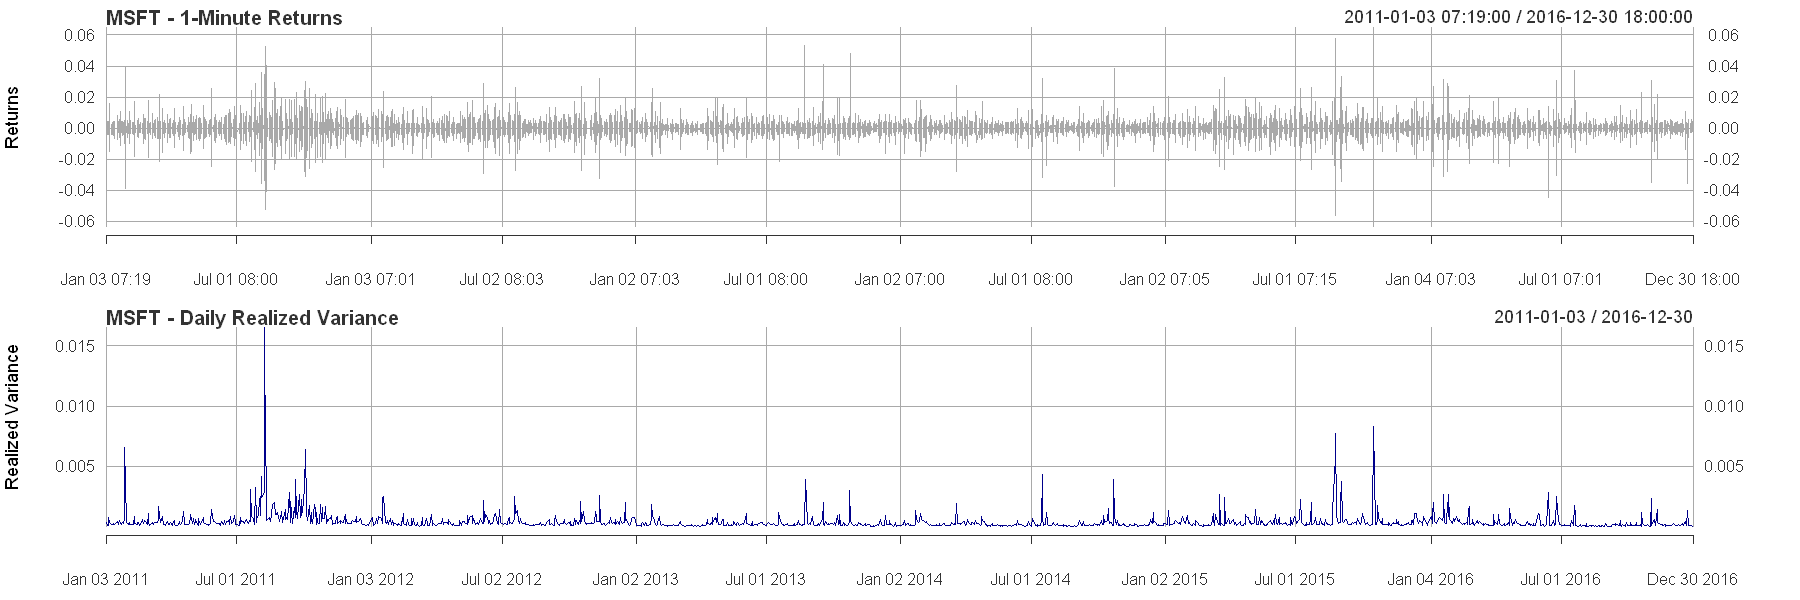


--- BAC RV Differences (Prices Method vs Returns Method) ---
Minimum Difference : 0.000000
Maximum Difference : 0.000000
Average Difference : 0.000000


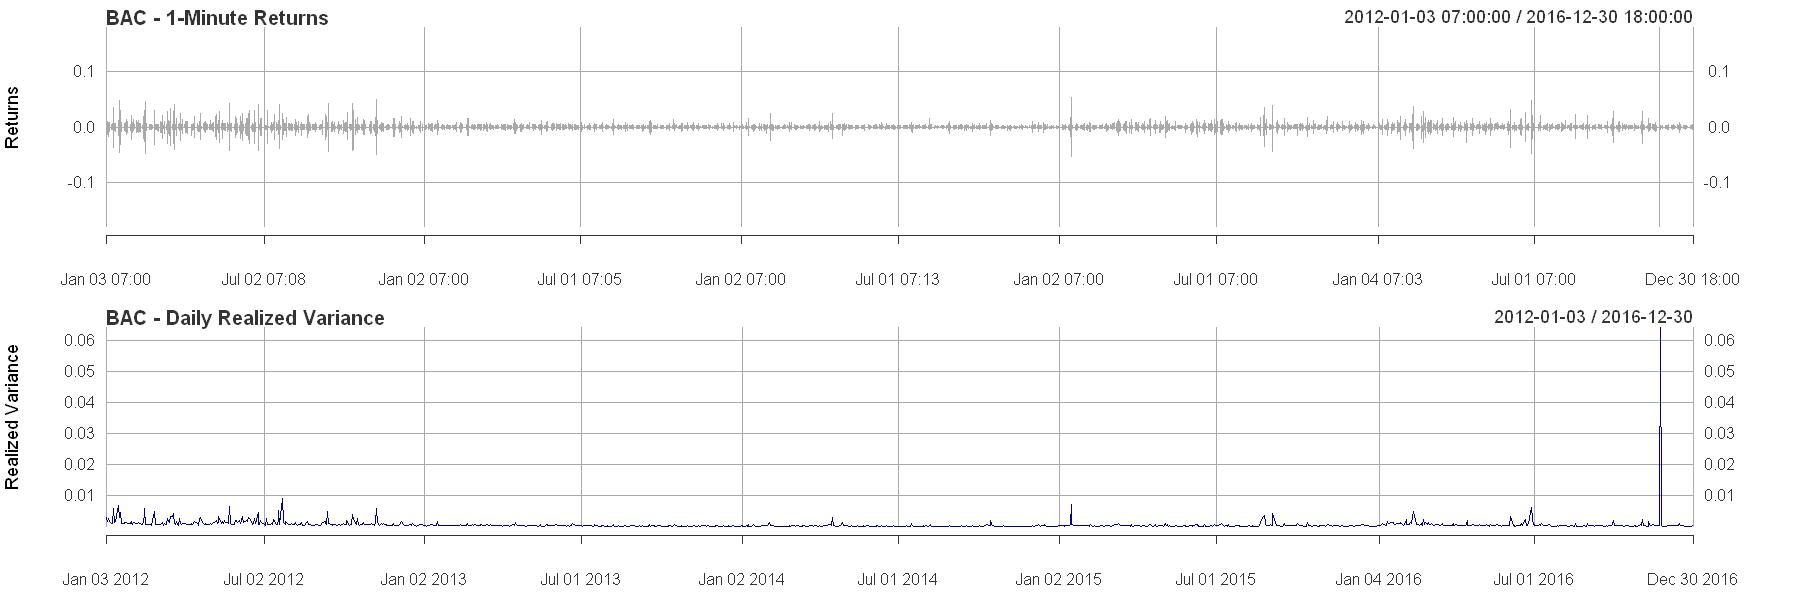


--- XOM RV Differences (Prices Method vs Returns Method) ---
Minimum Difference : 0.000000
Maximum Difference : 0.000000
Average Difference : 0.000000


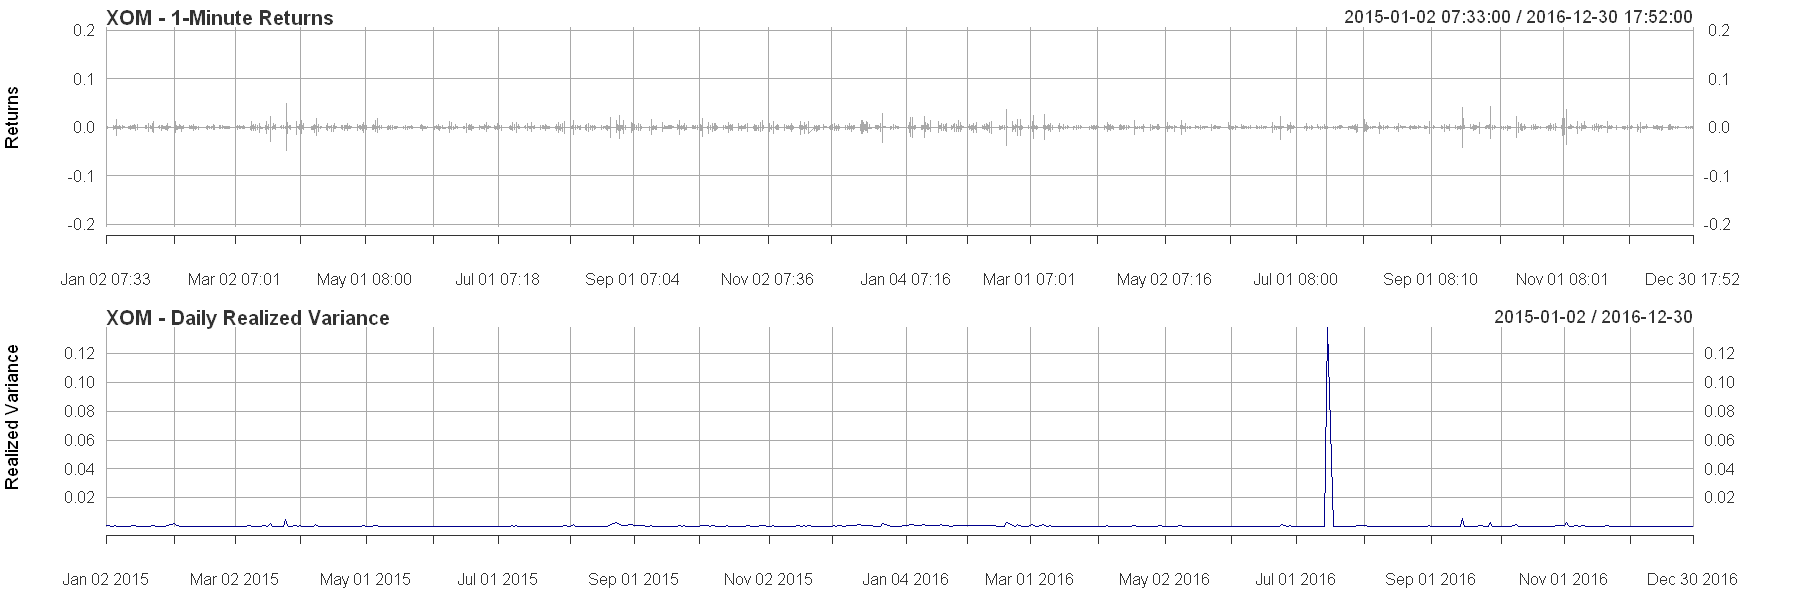

In [43]:
rv_msft <- compare_rv(msft_clean, "MSFT")
rv_bac  <- compare_rv(bac_clean,  "BAC")
rv_xom  <- compare_rv(xom_clean,  "XOM")

In [48]:
inspect_typo_window <- function(clean_data) {
  
  # 1. Find the event time again
  extreme_events <- clean_data[clean_data$Returns > 0.15]
  
  if (nrow(extreme_events) == 0) {
    cat("No extreme returns found.\n")
    return(NULL)
  }
  
  event_time <- index(extreme_events)[1]
  
  # 2. Create a narrow 10-minute window before and after
  # (Time math in R is done in seconds, so 10 mins = 600 seconds)
  window_start <- event_time - 2000 
  window_end   <- event_time + 2000
  
  # 3. Create the xts subset string (e.g., "2012-05-18 09:30:00/2012-05-18 09:50:00")
  time_subset <- paste0(window_start, "/", window_end)
  
  cat(sprintf("=== Inspecting 20-Minute Window ===\n"))
  cat(sprintf("Event Time: %s\n\n", event_time))
  
  # 4. Extract and print the raw prices for that window
  inspection_data <- clean_data[time_subset, "Price"]
  print(inspection_data)
  
  return(inspection_data)
}

In [49]:
xom_typo_check <- inspect_typo_window(xom_clean)

=== Inspecting 20-Minute Window ===
Event Time: 2016-07-15 08:37:00



Warning message:
"object timezone ('UTC') is different from system timezone ('')"


                      Price
2016-07-15 08:04:00 87.2420
2016-07-15 08:14:00 87.2880
2016-07-15 08:28:00 71.1518
2016-07-15 08:37:00 87.3522
2016-07-15 08:38:00 87.3706
2016-07-15 09:00:00 74.0774
2016-07-15 09:05:00 87.2420
2016-07-15 09:06:00 87.2420
2016-07-15 09:07:00 87.2420


that might be a data error, seems very suspisious

In [15]:
compare_subperiod_rv <- function(clean_data, ticker) {
  periods      <- c("T07:00/T09:29", "T09:30/T10:59", "T11:00/T14:29",
                    "T14:30/T15:59", "T16:00/T18:00")
  period_names <- c("07:00-09:29", "09:30-10:59", "11:00-14:29",
                    "14:30-15:59", "16:00-18:00")
 
  avg_rv       <- numeric(length(periods))
  daily_rv_list <- list()
 
  for (i in seq_along(periods)) {
    sub_returns      <- na.omit(clean_data[periods[i], "Returns"])
    daily_rv         <- rCov(sub_returns, makeReturns = FALSE)
    index(daily_rv)  <- as.Date(index(daily_rv))
    daily_rv_list[[i]] <- as.numeric(daily_rv)
    avg_rv[i]        <- mean(daily_rv, na.rm = TRUE)
  }
  names(daily_rv_list) <- period_names
 
  par(mfrow = c(1, 2), mar = c(7, 4, 4, 2) + 0.1)
 
  plot(avg_rv, type = "b", pch = 16, col = "red", lwd = 2, xaxt = "n",
       main = paste(ticker, "- Intraday Volatility Smile"),
       ylab = "Average Realized Variance", xlab = "Time Period")
  axis(1, at = 1:5, labels = period_names, las = 2)
 
  boxplot(daily_rv_list, names = period_names, col = "lightblue",
          main = paste(ticker, "- Daily RV Distribution"),
          ylab = "Daily Realized Variance", las = 2)
 
  par(mfrow = c(1, 1))
 
  cat(sprintf("\n--- %s Average Realized Variance by Period ---\n", ticker))
  for (i in seq_along(periods)) {
    cat(sprintf("%s : %f\n", period_names[i], avg_rv[i]))
  }
 
  return(list(
    avg_rv        = setNames(avg_rv, period_names),
    daily_rv_list = daily_rv_list
  ))
}


--- MSFT Average Realized Variance by Period ---
07:00-09:29 : 0.000070
09:30-10:59 : 0.000073
11:00-14:29 : 0.000054
14:30-15:59 : 0.000029
16:00-18:00 : 0.000224


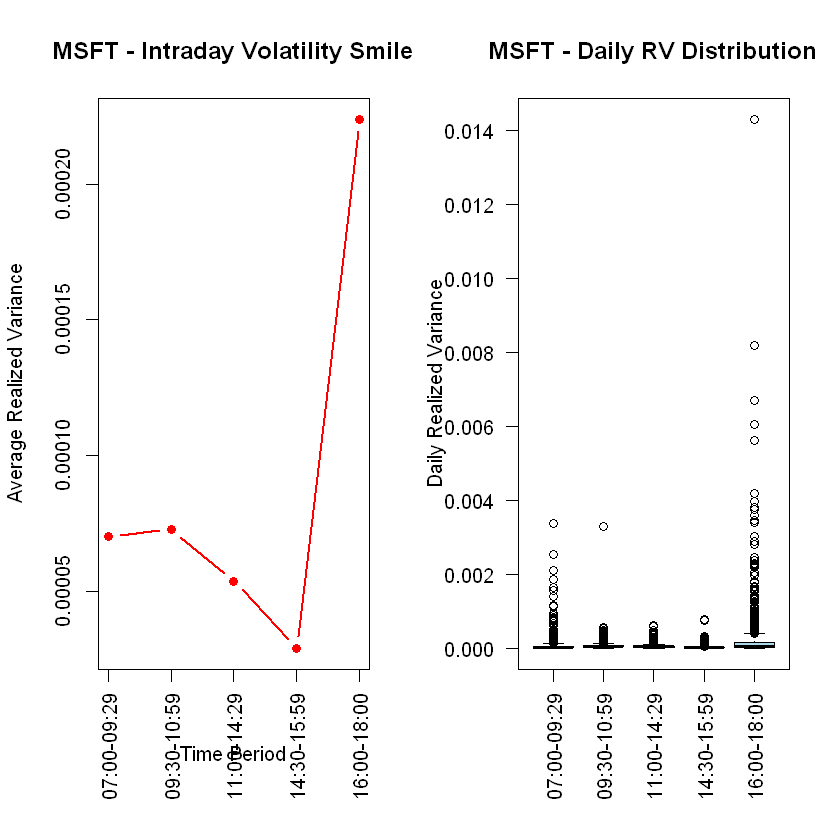


--- BAC Average Realized Variance by Period ---
07:00-09:29 : 0.000142
09:30-10:59 : 0.000130
11:00-14:29 : 0.000113
14:30-15:59 : 0.000051
16:00-18:00 : 0.000186


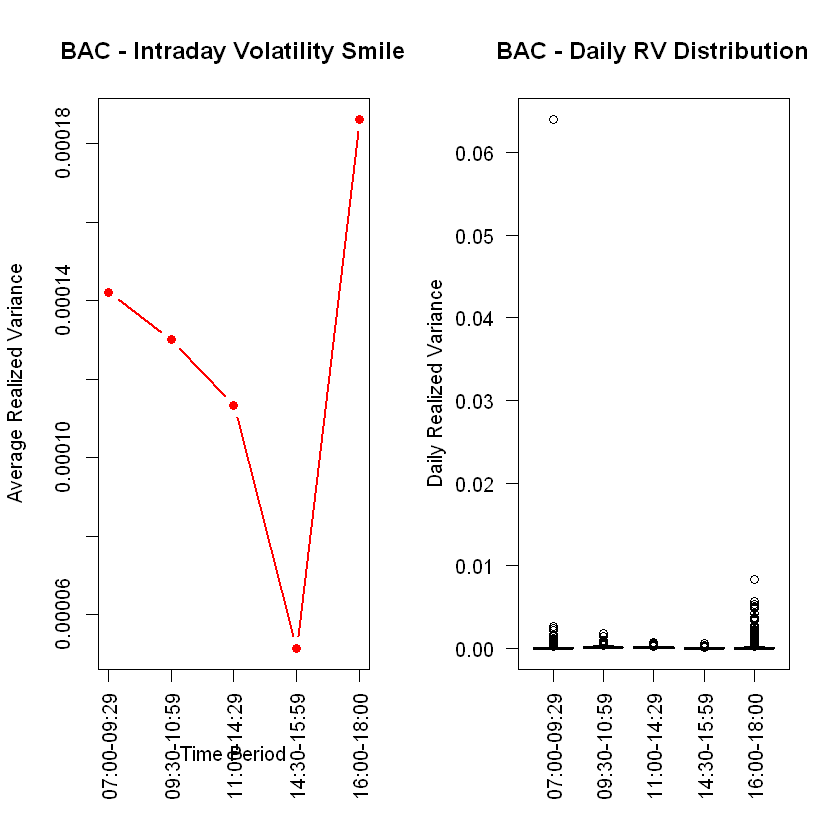


--- XOM Average Realized Variance by Period ---
07:00-09:29 : 0.000365
09:30-10:59 : 0.000070
11:00-14:29 : 0.000048
14:30-15:59 : 0.000023
16:00-18:00 : 0.000115


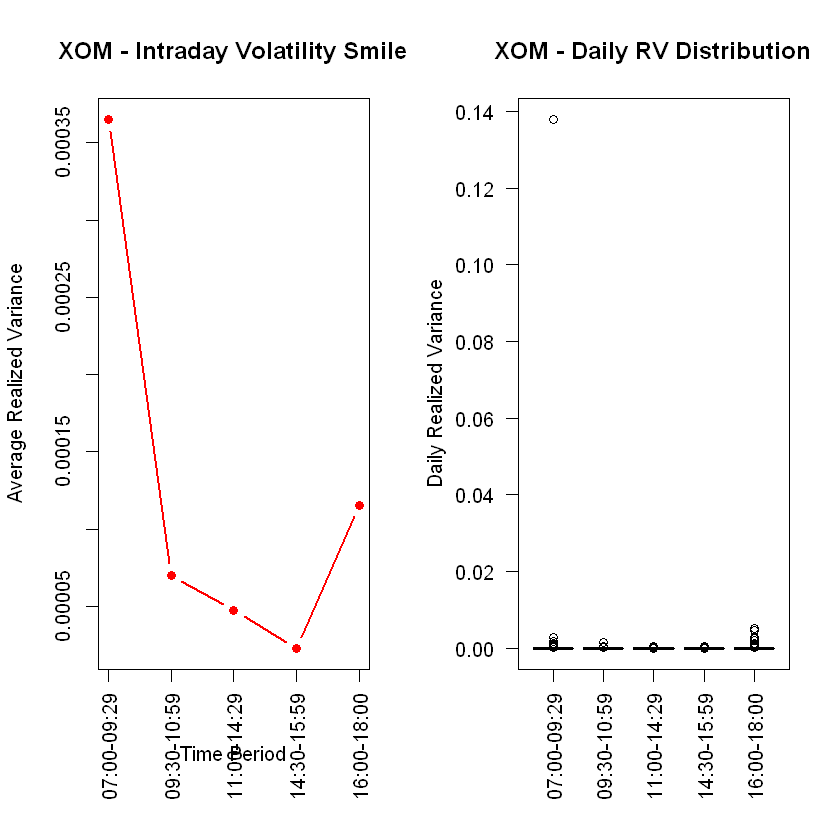

In [16]:
subperiod_msft <- compare_subperiod_rv(msft_clean, "MSFT")
subperiod_bac  <- compare_subperiod_rv(bac_clean,  "BAC")
subperiod_xom  <- compare_subperiod_rv(xom_clean,  "XOM")

In [17]:
compare_rv_additivity <- function(clean_data, ticker) {
  periods <- c("T07:00/T09:29", "T09:30/T10:59", "T11:00/T14:29",
               "T14:30/T15:59", "T16:00/T18:00")
 
  # Full daily RV must use the same 07:00-18:00 window as the sub-periods so
  # the comparison is symmetric. Using the raw Returns column without a time
  # filter would include returns outside this window, making the total
  # incomparable to the sub-period sum even when additivity holds perfectly.
  rv_daily <- rCov(na.omit(clean_data["T07:00/T18:00", "Returns"]), makeReturns = FALSE)
  index(rv_daily) <- as.Date(index(rv_daily))
  colnames(rv_daily) <- "Full_RV"
 
  combined_rvs <- rv_daily
  for (i in seq_along(periods)) {
    sub_ret      <- na.omit(clean_data[periods[i], "Returns"])
    daily_sub_rv <- rCov(sub_ret, makeReturns = FALSE)
    index(daily_sub_rv) <- as.Date(index(daily_sub_rv))
    colnames(daily_sub_rv) <- paste0("P", i)
    combined_rvs <- merge(combined_rvs, daily_sub_rv, join = "left")
  }
 
  combined_rvs[is.na(combined_rvs)] <- 0
 
  rv_summed <- rowSums(combined_rvs[, 2:6])
  rv_diff   <- combined_rvs[, 1] - rv_summed
 
  par(mar = c(7, 4, 4, 2) + 0.1)
  print(plot(rv_diff,
             main = paste(ticker, "Full RV vs. Summed RV"),
             col  = "darkgreen", ylab = "Difference"))
 
  cat(sprintf("\n--- %s Additivity Summary ---\n", ticker))
  cat(sprintf("Mean Difference: %e\n", mean(rv_diff, na.rm = TRUE)))
  cat(sprintf("Max Difference : %e\n", max(rv_diff,  na.rm = TRUE)))
  cat(sprintf("Min Difference : %e\n", min(rv_diff,  na.rm = TRUE)))
 
  return(list(
    rv_daily      = rv_daily,
    combined_rvs  = combined_rvs,
    rv_summed     = rv_summed,
    rv_diff       = rv_diff
  ))
}


--- MSFT Additivity Summary ---
Mean Difference: 2.513051e-22
Max Difference : 8.673617e-19
Min Difference : -8.673617e-19


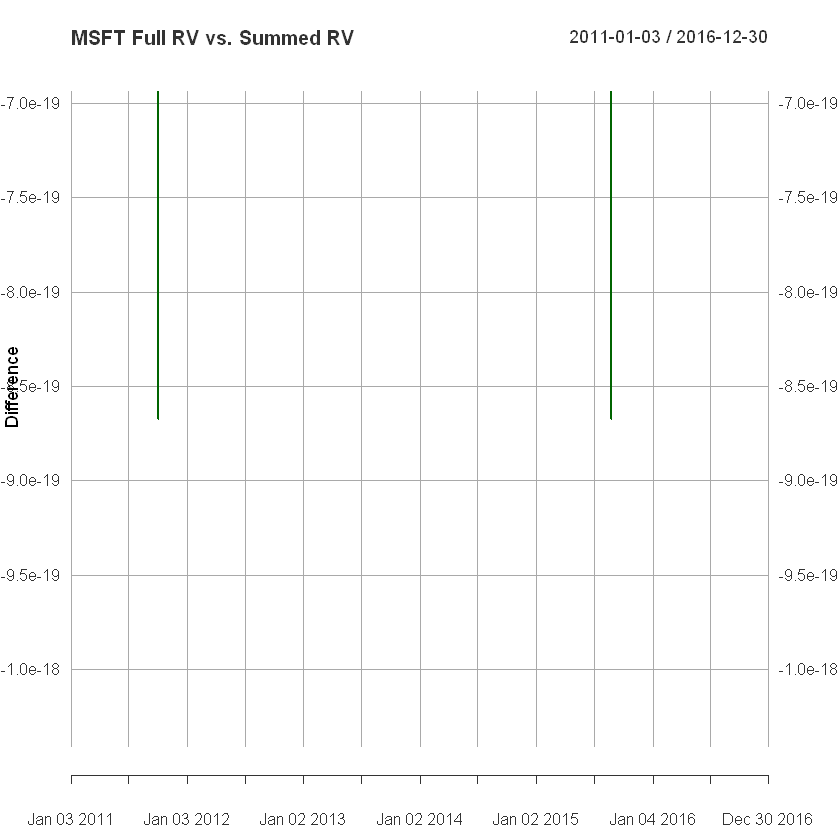


--- BAC Additivity Summary ---
Mean Difference: 1.249677e-21
Max Difference : 4.336809e-19
Min Difference : -8.673617e-19


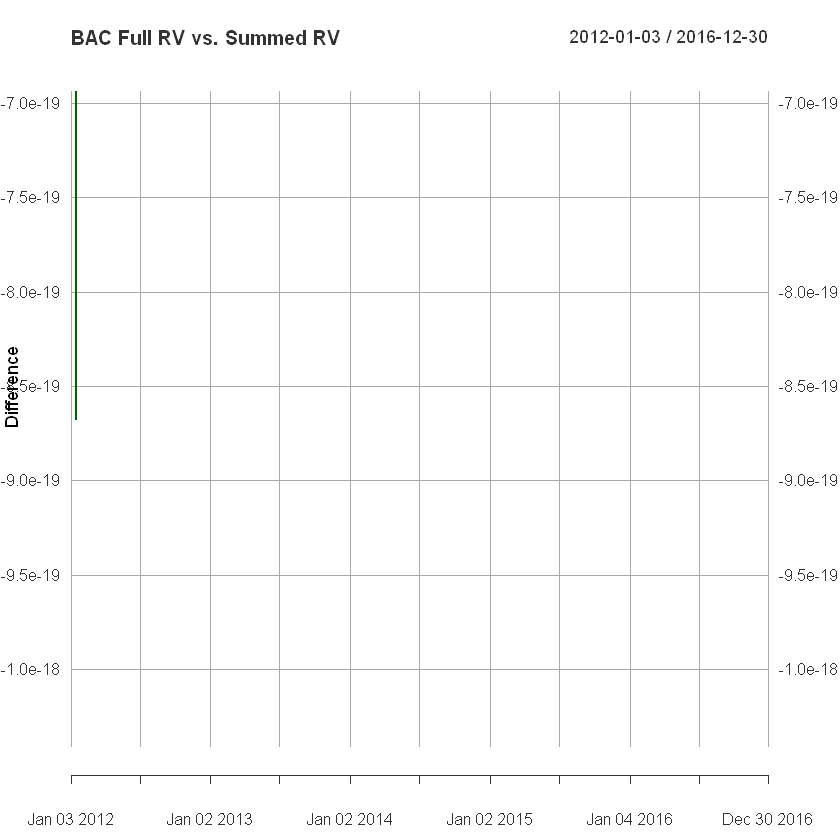


--- XOM Additivity Summary ---
Mean Difference: -5.399499e-20
Max Difference : 4.336809e-19
Min Difference : -2.775558e-17


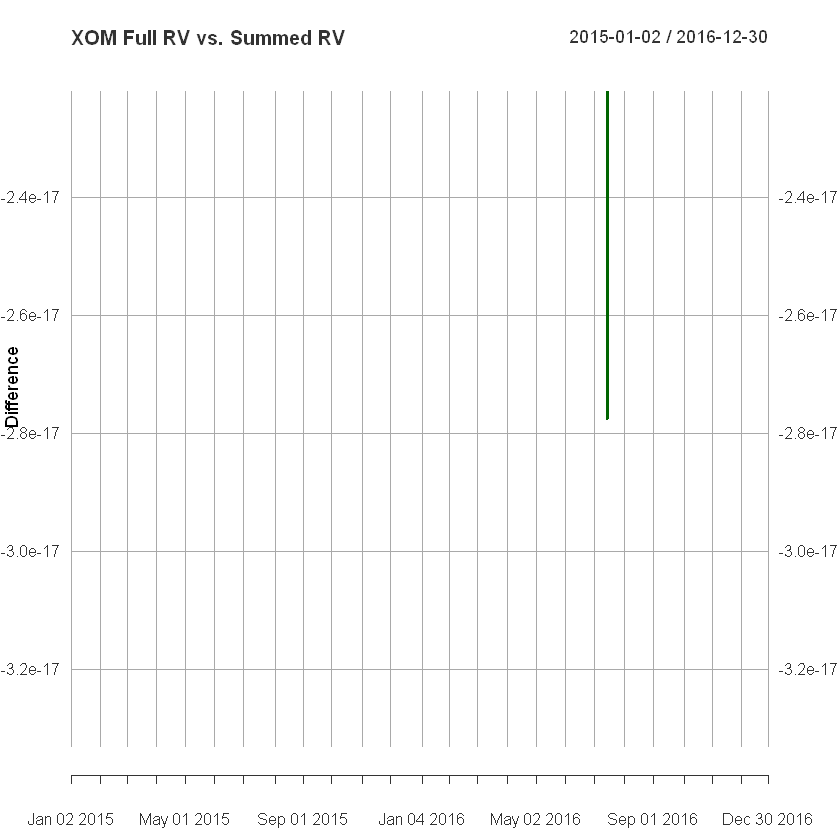

In [18]:
additivity_msft <- compare_rv_additivity(msft_clean, "MSFT")
additivity_bac  <- compare_rv_additivity(bac_clean,  "BAC")
additivity_xom  <- compare_rv_additivity(xom_clean,  "XOM")

In [19]:
plot_rv_shares <- function(clean_data, ticker) {
  periods <- list(
    "T07:00/T09:29" = "07:00-09:29",
    "T09:30/T10:59" = "09:30-10:59",
    "T11:00/T14:29" = "11:00-14:29",
    "T14:30/T15:59" = "14:30-15:59",
    "T16:00/T18:00" = "16:00-18:00"
  )
 
  # Use rCov directly on the time-filtered xts slice — it splits by day
  # internally, same as compare_subperiod_rv. Reassign index to plain Date
  # after each rCov call (seminar pattern) so merge() aligns correctly.
  rv_list <- lapply(names(periods), function(time_range) {
    sub_ret  <- na.omit(clean_data[time_range, "Returns"])
    daily_rv <- rCov(sub_ret, makeReturns = FALSE)
    index(daily_rv) <- as.Date(index(daily_rv))
    daily_rv
  })
 
  combined_rvs <- do.call(merge, rv_list)
  combined_rvs[is.na(combined_rvs)] <- 0
  colnames(combined_rvs) <- unlist(unname(periods))
 
  daily_total <- rowSums(combined_rvs)
  rv_shares   <- sweep(combined_rvs, 1, daily_total, FUN = "/") * 100
  rv_shares[daily_total == 0, ] <- 0
 
  mean_shares <- colMeans(rv_shares, na.rm = TRUE)
 
  bar_cols <- c("#2C7BB6", "#ABD9E9", "#FFFFBF", "#FDAE61", "#D7191C")
  bp <- barplot(mean_shares,
                main      = paste(ticker, "— Avg % Share of Intraday RV"),
                col       = bar_cols,
                ylim      = c(0, max(mean_shares, na.rm = TRUE) * 1.2),
                ylab      = "Percentage Share (%)",
                xlab      = "Intraday Period",
                las       = 2,
                border    = "white",
                cex.names = 0.85)
  text(x = bp, y = mean_shares,
       labels = paste0(round(mean_shares, 1), "%"),
       pos = 3, cex = 0.85, font = 2)
 
  cat(sprintf("\n=== %s — RV Share Breakdown ===\n", ticker))
  for (i in seq_along(mean_shares)) {
    cat(sprintf("  %-15s : %6.2f%%\n", names(mean_shares)[i], mean_shares[i]))
  }
  cat(sprintf("  %-15s : %6.2f%%\n", "TOTAL", sum(mean_shares)))
 
  return(list(
    combined_rvs = combined_rvs,
    daily_total  = daily_total,
    rv_shares    = rv_shares,
    mean_shares  = mean_shares
  ))
}


=== MSFT — RV Share Breakdown ===
  07:00-09:29     :  17.98%
  09:30-10:59     :  24.33%
  11:00-14:29     :  17.80%
  14:30-15:59     :   8.83%
  16:00-18:00     :  31.07%
  TOTAL           : 100.00%


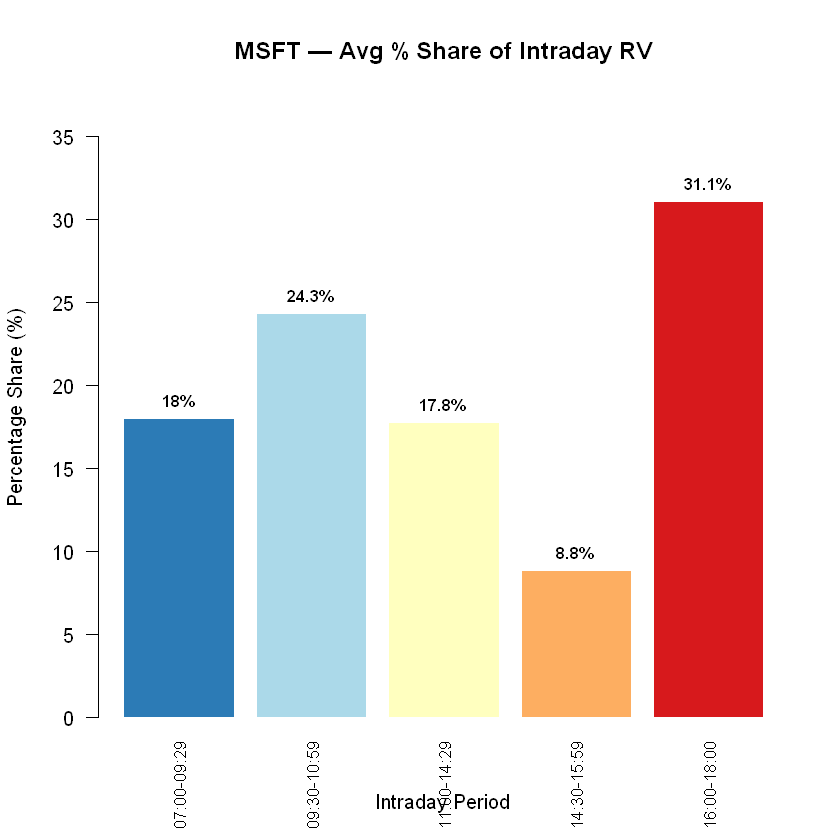


=== BAC — RV Share Breakdown ===
  07:00-09:29     :  17.24%
  09:30-10:59     :  29.13%
  11:00-14:29     :  25.05%
  14:30-15:59     :  10.90%
  16:00-18:00     :  17.68%
  TOTAL           : 100.00%


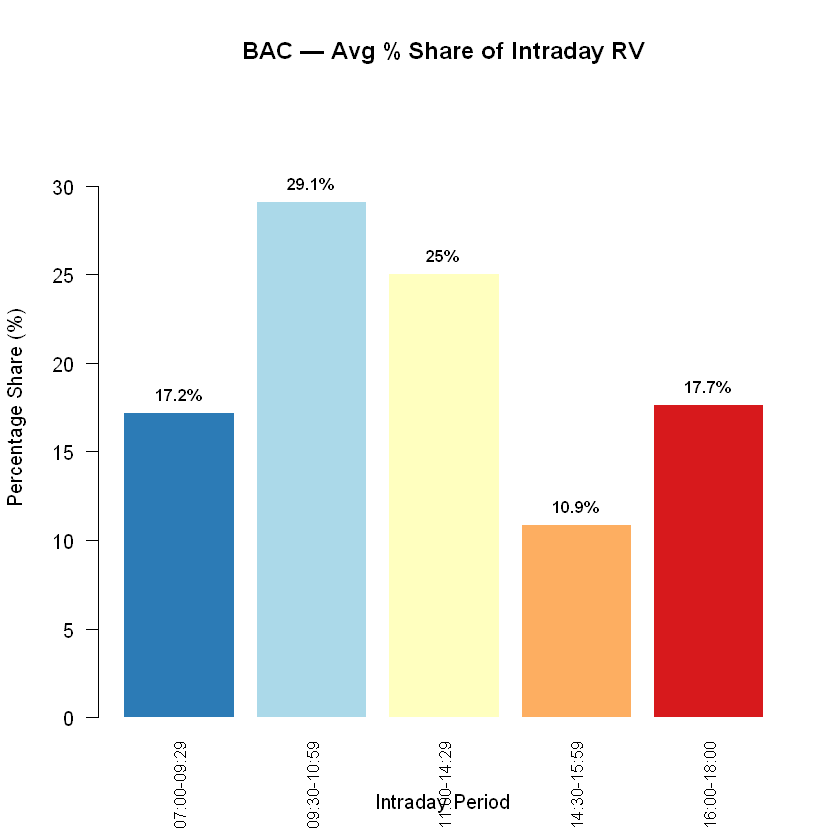


=== XOM — RV Share Breakdown ===
  07:00-09:29     :  25.35%
  09:30-10:59     :  27.03%
  11:00-14:29     :  18.70%
  14:30-15:59     :   8.12%
  16:00-18:00     :  20.79%
  TOTAL           : 100.00%


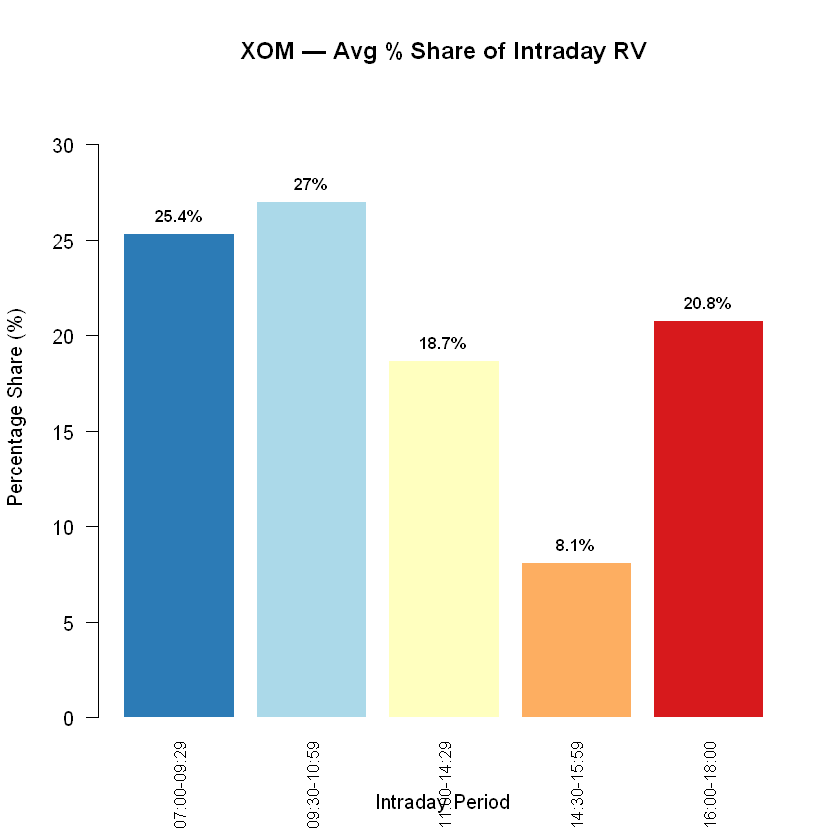

In [20]:
shares_msft <- plot_rv_shares(msft_clean, "MSFT")
shares_bac  <- plot_rv_shares(bac_clean,  "BAC")
shares_xom  <- plot_rv_shares(xom_clean,  "XOM")

In [25]:
compare_subperiod_rv_prices <- function(clean_data, ticker) {
  periods      <- c("T07:00/T09:29", "T09:30/T10:59", "T11:00/T14:29",
                    "T14:30/T15:59", "T16:00/T18:00")
  period_names <- c("07:00-09:29", "09:30-10:59", "11:00-14:29",
                    "14:30-15:59", "16:00-18:00")
 
  avg_rv        <- numeric(length(periods))
  daily_rv_list <- list()
 
  for (i in seq_along(periods)) {
    # Use Price column; rCov will call makeReturns internally.
    # Drop any day with fewer than 2 price observations in this window —
    # makeReturns needs at least 2 prices to compute a return and throws
    # "subscript out of bounds" otherwise. This mirrors how na.omit protects
    # the returns-based version in compare_subperiod_rv.
    sub_prices <- clean_data[periods[i], "Price"]
    sub_prices <- do.call(rbind, Filter(function(d) nrow(d) >= 2,
                                        split(sub_prices, "days")))
    daily_rv         <- rCov(sub_prices, makeReturns = TRUE)
    index(daily_rv)  <- as.Date(index(daily_rv))
    daily_rv_list[[i]] <- as.numeric(daily_rv)
    avg_rv[i]        <- mean(daily_rv, na.rm = TRUE)
  }
  names(daily_rv_list) <- period_names
 
  par(mfrow = c(1, 2), mar = c(7, 4, 4, 2) + 0.1)
 
  plot(avg_rv, type = "b", pch = 16, col = "red", lwd = 2, xaxt = "n",
       main = paste(ticker, "- Intraday Volatility Smile (Prices)"),
       ylab = "Average Realized Variance", xlab = "Time Period")
  axis(1, at = 1:5, labels = period_names, las = 2)
 
  boxplot(daily_rv_list, names = period_names, col = "lightblue",
          main = paste(ticker, "- Daily RV Distribution (Prices)"),
          ylab = "Daily Realized Variance", las = 2)
 
  par(mfrow = c(1, 1))
 
  cat(sprintf("\n--- %s Average RV by Period (Prices) ---\n", ticker))
  for (i in seq_along(periods)) {
    cat(sprintf("%s : %f\n", period_names[i], avg_rv[i]))
  }
 
  return(list(
    avg_rv        = setNames(avg_rv, period_names),
    daily_rv_list = daily_rv_list
  ))
}


--- MSFT Average RV by Period (Prices) ---
07:00-09:29 : 0.000070
09:30-10:59 : 0.000065
11:00-14:29 : 0.000053
14:30-15:59 : 0.000029
16:00-18:00 : 0.000221


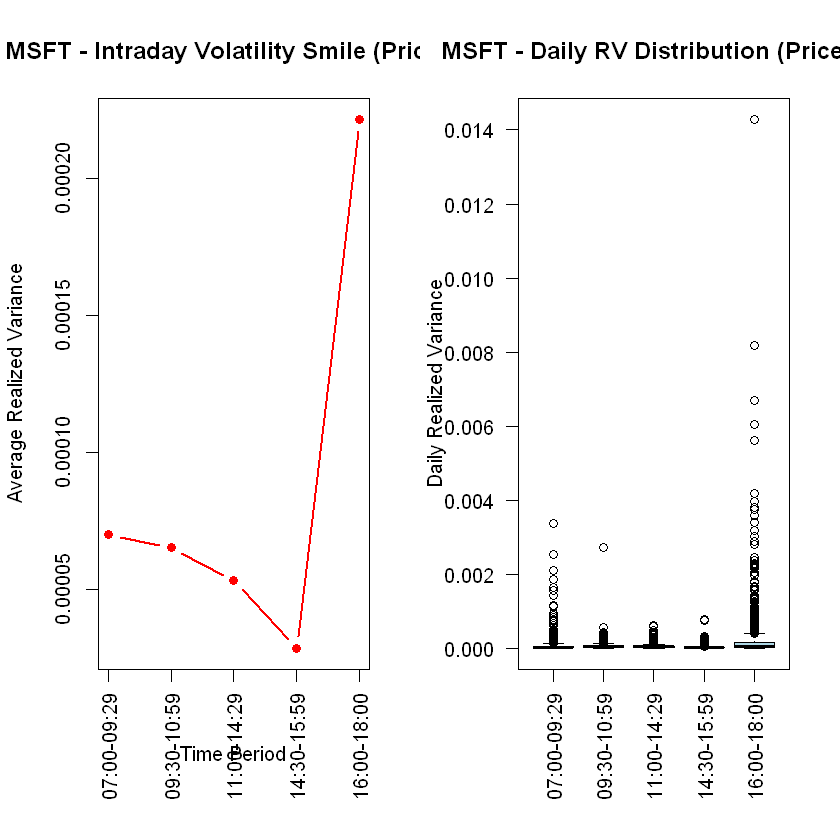


--- BAC Average RV by Period (Prices) ---
07:00-09:29 : 0.000142
09:30-10:59 : 0.000123
11:00-14:29 : 0.000113
14:30-15:59 : 0.000051
16:00-18:00 : 0.000184


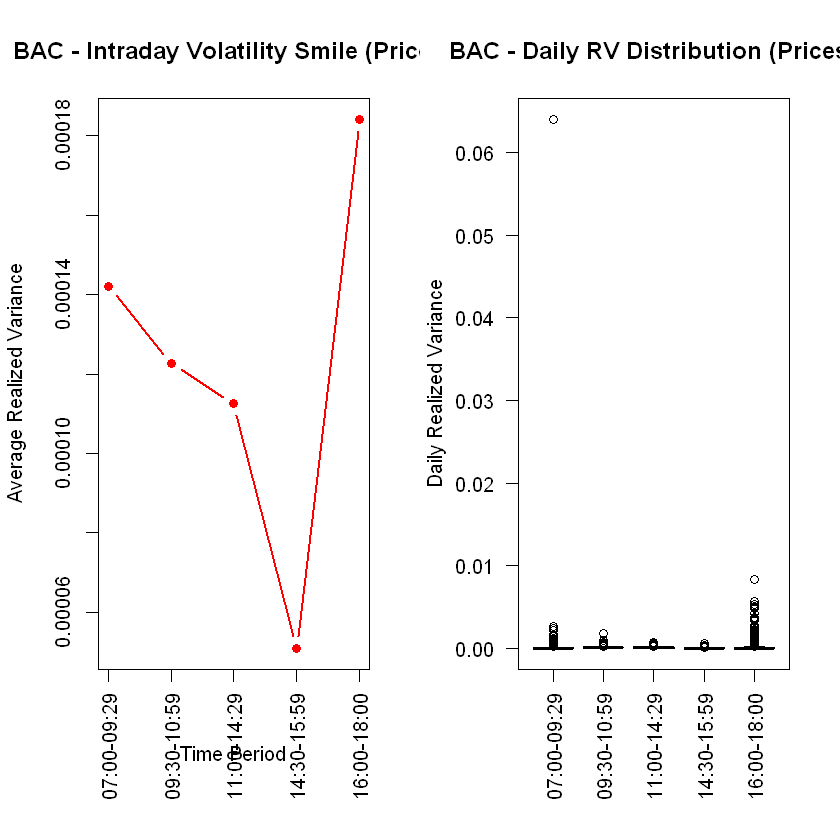


--- XOM Average RV by Period (Prices) ---
07:00-09:29 : 0.000366
09:30-10:59 : 0.000064
11:00-14:29 : 0.000047
14:30-15:59 : 0.000023
16:00-18:00 : 0.000109


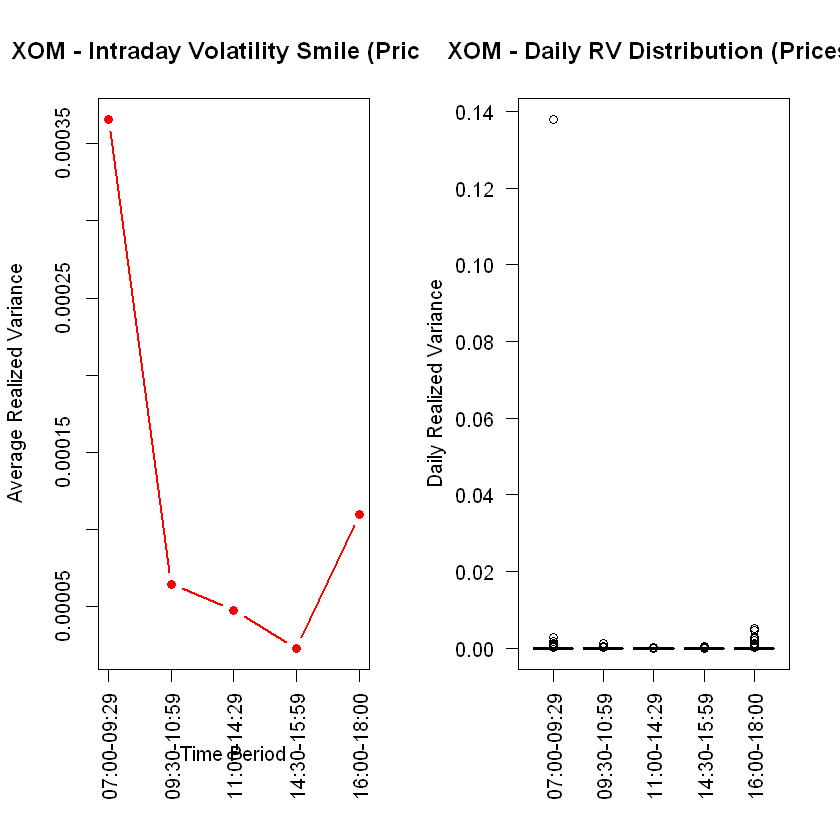

In [26]:
subperiod_prices_msft <- compare_subperiod_rv_prices(msft_clean, "MSFT")
subperiod_prices_bac  <- compare_subperiod_rv_prices(bac_clean,  "BAC")
subperiod_prices_xom  <- compare_subperiod_rv_prices(xom_clean,  "XOM")

In [29]:
compare_rv_additivity_prices <- function(clean_data, ticker) {
  periods <- c("T07:00/T09:29", "T09:30/T10:59", "T11:00/T14:29",
               "T14:30/T15:59", "T16:00/T18:00")
 
  # Full daily RV must use the same 07:00-18:00 window as the sub-periods.
  # rCov(prices, makeReturns=TRUE) on the unrestricted Price column would
  # include the overnight return (last price of previous day -> first price of
  # current day), inflating the full RV relative to the sub-period sum and
  # making the additivity breakdown misleading.
  # Filter guard: drop days with fewer than 2 prices before any rCov call
  # with makeReturns=TRUE, otherwise makeReturns crashes with
  # "subscript out of bounds" on single-observation days.
  full_prices <- do.call(rbind, Filter(function(d) nrow(d) >= 2,
                                       split(clean_data["T07:00/T18:00", "Price"], "days")))
  rv_daily <- rCov(full_prices, makeReturns = TRUE)
  index(rv_daily) <- as.Date(index(rv_daily))
  colnames(rv_daily) <- "Full_RV"
 
  combined_rvs <- rv_daily
  for (i in seq_along(periods)) {
    sub_prices   <- clean_data[periods[i], "Price"]
    sub_prices   <- do.call(rbind, Filter(function(d) nrow(d) >= 2,
                                          split(sub_prices, "days")))
    daily_sub_rv <- rCov(sub_prices, makeReturns = TRUE)
    index(daily_sub_rv) <- as.Date(index(daily_sub_rv))
    colnames(daily_sub_rv) <- paste0("P", i)
    combined_rvs <- merge(combined_rvs, daily_sub_rv, join = "left")
  }
 
  combined_rvs[is.na(combined_rvs)] <- 0
 
  rv_summed <- rowSums(combined_rvs[, 2:6])
  rv_diff   <- combined_rvs[, 1] - rv_summed
 
  par(mar = c(7, 4, 4, 2) + 0.1)
  print(plot(rv_diff,
             main = paste(ticker, "Full RV vs. Summed RV (Prices)"),
             col  = "darkred", ylab = "Difference"))
 
  cat(sprintf("\n--- %s Additivity Summary (Prices) ---\n", ticker))
  cat(sprintf("Mean Difference: %e\n", mean(rv_diff, na.rm = TRUE)))
  cat(sprintf("Max Difference : %e\n", max(rv_diff,  na.rm = TRUE)))
  cat(sprintf("Min Difference : %e\n", min(rv_diff,  na.rm = TRUE)))
 
  return(list(
    rv_daily     = rv_daily,
    combined_rvs = combined_rvs,
    rv_summed    = rv_summed,
    rv_diff      = rv_diff
  ))
}


--- MSFT Additivity Summary (Prices) ---
Mean Difference: 1.133591e-05
Max Difference : 5.816547e-04
Min Difference : 4.908979e-08


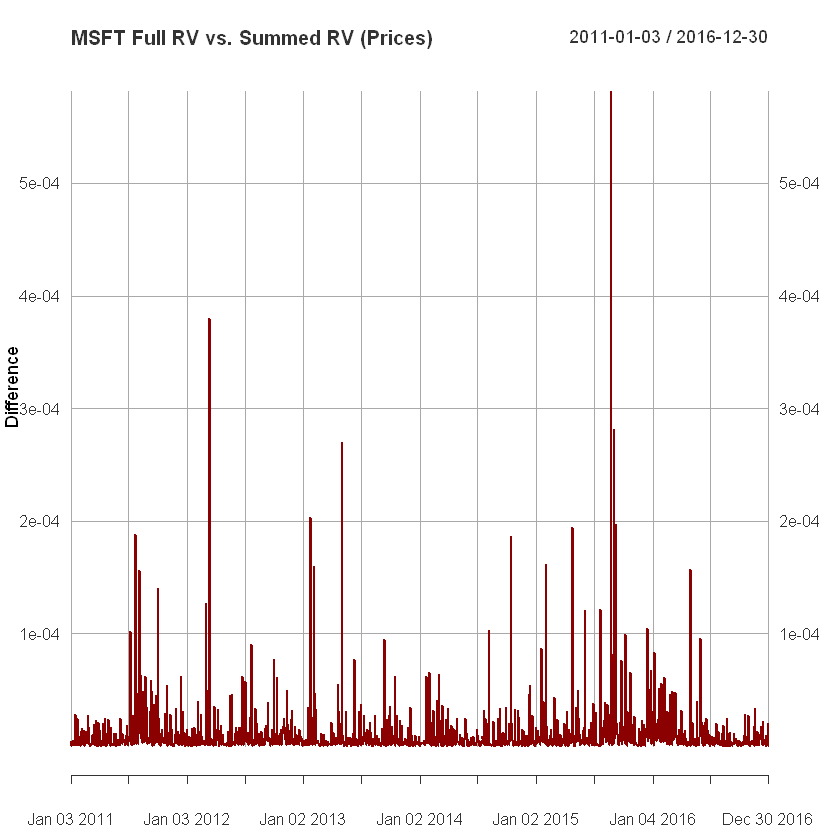


--- BAC Additivity Summary (Prices) ---
Mean Difference: 1.088050e-05
Max Difference : 1.305758e-03
Min Difference : 0.000000e+00


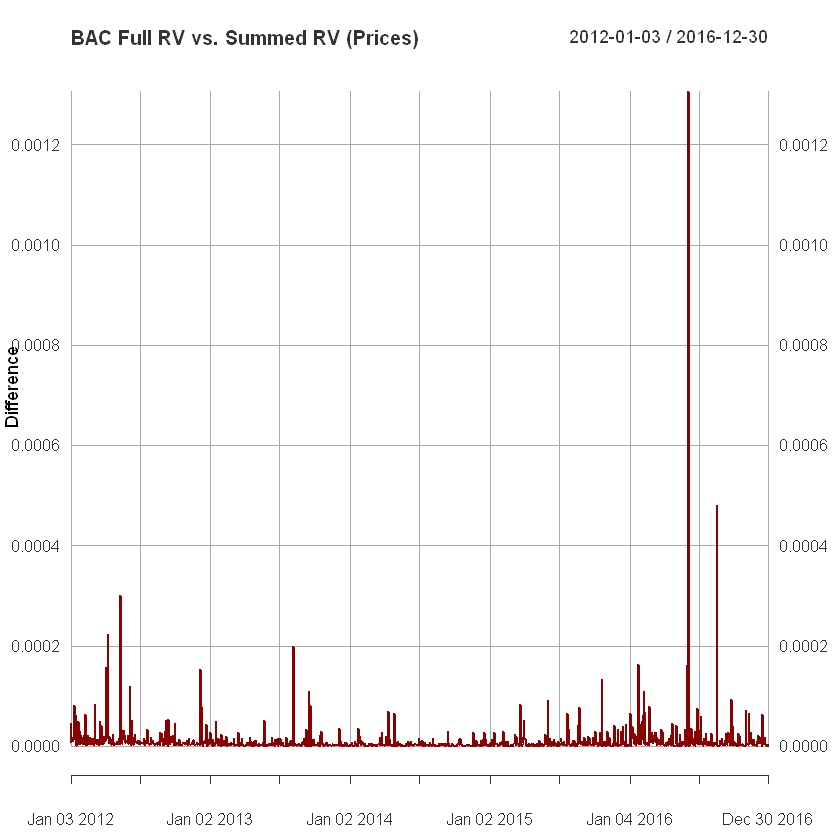


--- XOM Additivity Summary (Prices) ---
Mean Difference: 1.278990e-05
Max Difference : 6.081737e-04
Min Difference : 1.102755e-08


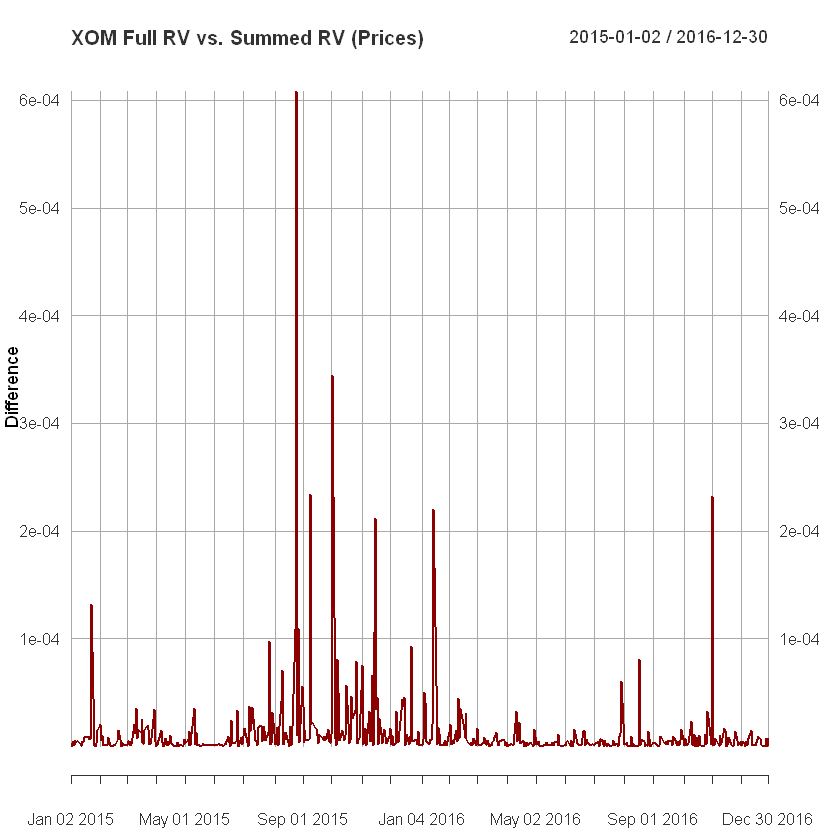

In [30]:
additivity_prices_msft <- compare_rv_additivity_prices(msft_clean, "MSFT")
additivity_prices_bac  <- compare_rv_additivity_prices(bac_clean,  "BAC")
additivity_prices_xom  <- compare_rv_additivity_prices(xom_clean,  "XOM")

In [33]:
plot_rv_shares_prices <- function(clean_data, ticker) {
  periods <- list(
    "T07:00/T09:29" = "07:00-09:29",
    "T09:30/T10:59" = "09:30-10:59",
    "T11:00/T14:29" = "11:00-14:29",
    "T14:30/T15:59" = "14:30-15:59",
    "T16:00/T18:00" = "16:00-18:00"
  )
 
  rv_list <- lapply(names(periods), function(time_range) {
    sub_prices <- clean_data[time_range, "Price"]
    sub_prices <- do.call(rbind, Filter(function(d) nrow(d) >= 2,
                                        split(sub_prices, "days")))
    daily_rv   <- rCov(sub_prices, makeReturns = TRUE)
    index(daily_rv) <- as.Date(index(daily_rv))
    daily_rv
  })
 
  combined_rvs <- do.call(merge, rv_list)
  combined_rvs[is.na(combined_rvs)] <- 0
  colnames(combined_rvs) <- unlist(unname(periods))
 
  daily_total <- rowSums(combined_rvs)
  rv_shares   <- sweep(combined_rvs, 1, daily_total, FUN = "/") * 100
  rv_shares[daily_total == 0, ] <- 0
 
  mean_shares <- colMeans(rv_shares, na.rm = TRUE)
 
  bar_cols <- c("#2C7BB6", "#ABD9E9", "#FFFFBF", "#FDAE61", "#D7191C")
  bp <- barplot(mean_shares,
                main      = paste(ticker, "— Avg % Share of Intraday RV (Prices)"),
                col       = bar_cols,
                ylim      = c(0, max(mean_shares, na.rm = TRUE) * 1.2),
                ylab      = "Percentage Share (%)",
                xlab      = "Intraday Period",
                las       = 2,
                border    = "white",
                cex.names = 0.85)
  text(x = bp, y = mean_shares,
       labels = paste0(round(mean_shares, 1), "%"),
       pos = 3, cex = 0.85, font = 2)
 
  cat(sprintf("\n=== %s — RV Share Breakdown (Prices) ===\n", ticker))
  for (i in seq_along(mean_shares)) {
    cat(sprintf("  %-15s : %6.2f%%\n", names(mean_shares)[i], mean_shares[i]))
  }
  cat(sprintf("  %-15s : %6.2f%%\n", "TOTAL", sum(mean_shares)))
 
  return(list(
    combined_rvs = combined_rvs,
    daily_total  = daily_total,
    rv_shares    = rv_shares,
    mean_shares  = mean_shares
  ))
}


=== MSFT — RV Share Breakdown (Prices) ===
  07:00-09:29     :  18.61%
  09:30-10:59     :  22.87%
  11:00-14:29     :  18.31%
  14:30-15:59     :   9.04%
  16:00-18:00     :  31.18%
  TOTAL           : 100.00%


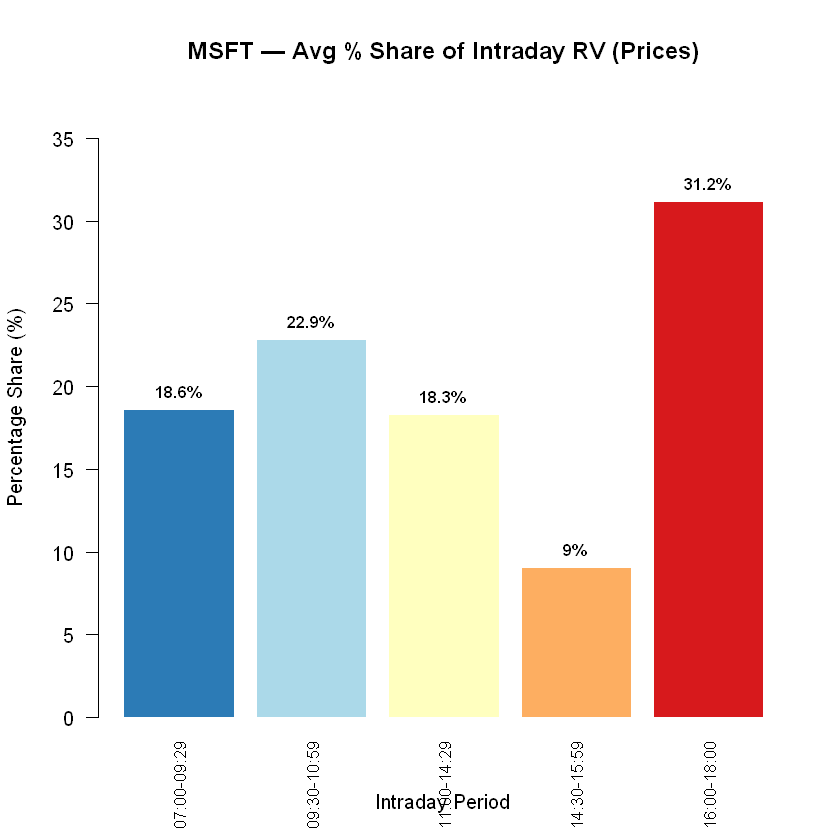


=== BAC — RV Share Breakdown (Prices) ===
  07:00-09:29     :  17.67%
  09:30-10:59     :  28.27%
  11:00-14:29     :  25.43%
  14:30-15:59     :  11.01%
  16:00-18:00     :  17.63%
  TOTAL           : 100.00%


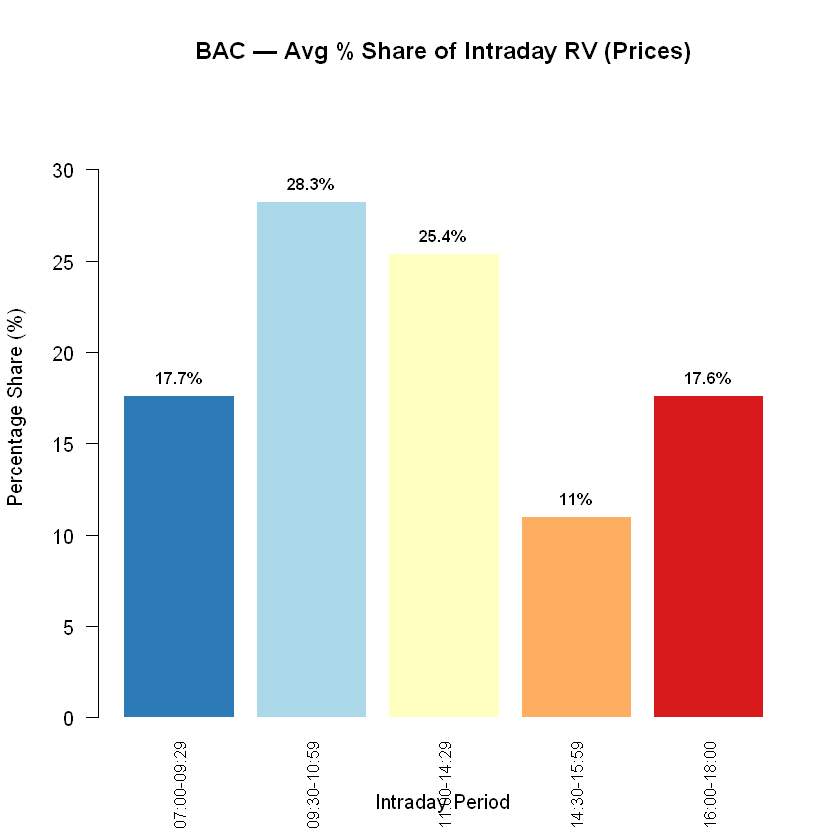


=== XOM — RV Share Breakdown (Prices) ===
  07:00-09:29     :  26.34%
  09:30-10:59     :  25.86%
  11:00-14:29     :  19.24%
  14:30-15:59     :   8.35%
  16:00-18:00     :  20.20%
  TOTAL           : 100.00%


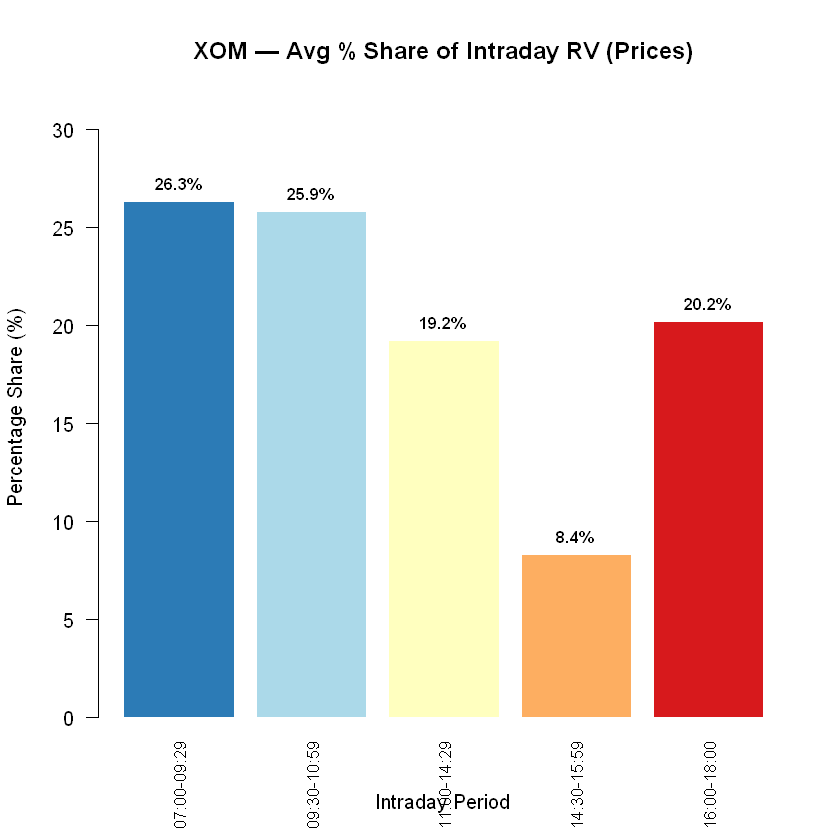

In [34]:
shares_prices_msft <- plot_rv_shares_prices(msft_clean, "MSFT")
shares_prices_bac  <- plot_rv_shares_prices(bac_clean,  "BAC")
shares_prices_xom  <- plot_rv_shares_prices(xom_clean,  "XOM")

In [59]:
options(repr.plot.width = 18, repr.plot.height = 7)

In [64]:
compute_jumps <- function(clean_data, ticker, rv_result) {
 
  returns <- na.omit(clean_data[, "Returns"])
 
  # 1. Reuse RV already computed in exercise 4 (from returns)
  RV <- rv_result$rv_returns                         # xts, Date-indexed
 
  # 2. Bipower Variation via highfrequency package
  BPV <- rBPCov(rData = returns)
  index(BPV) <- as.Date(index(BPV))
 
  # 3. MedRV via highfrequency package
  MedRV <- rMedRVar(rData = returns)
  index(MedRV) <- as.Date(index(MedRV))
 
  # 4. Raw jump series (RV - BPV) and (RV - MedRV)
  # Negative values can appear due to sampling noise — set to 0 after testing
  j_BPV   <- RV - BPV
  j_MedRV <- RV - MedRV
 
  # 5. Jump significance tests (Barndorff-Nielsen & Shephard)
  # BV  = standard BPV-based test, TP = tripower quarticity as IQ estimator
  # rMedRVar / rMedRQuar = MedRV-based test (more robust to microstructure noise)
  jump_test_BPV   <- BNSjumpTest(returns, IVestimator = "BV",       IQestimator = "TP")
  jump_test_MedRV <- BNSjumpTest(returns, IVestimator = "rMedRVar", IQestimator = "rMedRQuar")
 
  index(jump_test_BPV)   <- as.Date(index(jump_test_BPV))
  index(jump_test_MedRV) <- as.Date(index(jump_test_MedRV))
 
  # 6. Indicator function: 1 if jump is significant at 5%, else 0
  TT <- nrow(RV)
  I_BPV   <- as.numeric(jump_test_BPV[,   "p.value"] < 0.05)
  I_MedRV <- as.numeric(jump_test_MedRV[, "p.value"] < 0.05)
 
  # 7. Significant jump variation only (zero out insignificant days)
  JV_BPV   <- j_BPV   * I_BPV
  JV_MedRV <- j_MedRV * I_MedRV
 
  # Clamp negatives to 0 (noise-induced negatives are not true jumps)
  JV_BPV[JV_BPV     < 0] <- 0
  JV_MedRV[JV_MedRV < 0] <- 0
 
  # 8. Console summary
  cat(sprintf("\n=== %s — Jump Summary ===\n", ticker))
  cat(sprintf("Significant jump days (BPV test)  : %d / %d (%.1f%%)\n",
              sum(I_BPV),   TT, 100 * mean(I_BPV)))
  cat(sprintf("Significant jump days (MedRV test): %d / %d (%.1f%%)\n",
              sum(I_MedRV), TT, 100 * mean(I_MedRV)))
  cat(sprintf("Mean RV   : %.6f\n", mean(RV,    na.rm = TRUE)))
  cat(sprintf("Mean BPV  : %.6f\n", mean(BPV,   na.rm = TRUE)))
  cat(sprintf("Mean MedRV: %.6f\n", mean(MedRV, na.rm = TRUE)))
 
  # 9. Plots — three panels per ticker
  par(mfrow = c(1, 3), mar = c(4, 4, 3, 1))
 
  # Panel A: RV vs BPV vs MedRV over time
  plot.zoo(sqrt(RV), col = "black", lwd = 1,
           main = paste(ticker, "— RVol, BPV, MedRV"),
           ylab = "Volatility", xlab = NA)
  lines(zoo(sqrt(BPV)),   col = "steelblue", lwd = 1)
  lines(zoo(sqrt(MedRV)), col = "tomato",    lwd = 1)
  legend("topright", legend = c("RVol", "sqrt(BPV)", "sqrt(MedRV)"),
         col = c("black", "steelblue", "tomato"), lwd = 2, bty = "n", cex = 1.2)
 
  # Panel B: significant jump variation from both tests
  plot.zoo(JV_BPV, col = "steelblue", lwd = 2, type = "h",
           main = paste(ticker, "— Significant Jumps"),
           ylab = "Jump Variation", xlab = NA,
           ylim = c(0, max(max(JV_BPV), max(JV_MedRV), na.rm = TRUE) * 1.1))
  lines(zoo(JV_MedRV), col = "tomato", lwd = 2, type = "h")
  legend("topright", legend = c("RV - BPV", "RV - MedRV"),
         col = c("steelblue", "tomato"), lwd = 2, bty = "n", cex = 1.2)
 
  # Panel C: BPV + significant jumps vs RV (should reconstruct RV well)
  plot.zoo(sqrt(RV), col = "black", lwd = 1,
           main = paste(ticker, "— BPV + Jumps vs RV"),
           ylab = "Volatility", xlab = NA)
  lines(zoo(sqrt(BPV + JV_BPV)), col = "steelblue", lwd = 1, lty = 1)
  lines(zoo(sqrt(MedRV + JV_MedRV)), col = "tomato", lwd = 1, lty = 1)
  legend("topright", legend = c("RVol", "sqrt(BPV+J)", "sqrt(MedRV+J)"),
         col = c("black", "steelblue", "tomato"), lwd = 2, lty = c(1,1,1),
         bty = "n", cex = 1,2)
 
  par(mfrow = c(1, 1))
 
  return(list(
    RV             = RV,
    BPV            = BPV,
    MedRV          = MedRV,
    j_BPV          = j_BPV,
    j_MedRV        = j_MedRV,
    jump_test_BPV  = jump_test_BPV,
    jump_test_MedRV= jump_test_MedRV,
    I_BPV          = I_BPV,
    I_MedRV        = I_MedRV,
    JV_BPV         = JV_BPV,
    JV_MedRV       = JV_MedRV
  ))
}


=== MSFT — Jump Summary ===
Significant jump days (BPV test)  : 672 / 1510 (44.5%)
Significant jump days (MedRV test): 145 / 1510 (9.6%)
Mean RV   : 0.000449
Mean BPV  : 0.000394
Mean MedRV: 0.000486

=== BAC — Jump Summary ===
Significant jump days (BPV test)  : 892 / 1258 (70.9%)
Significant jump days (MedRV test): 181 / 1258 (14.4%)
Mean RV   : 0.000623
Mean BPV  : 0.000526
Mean MedRV: 0.000699


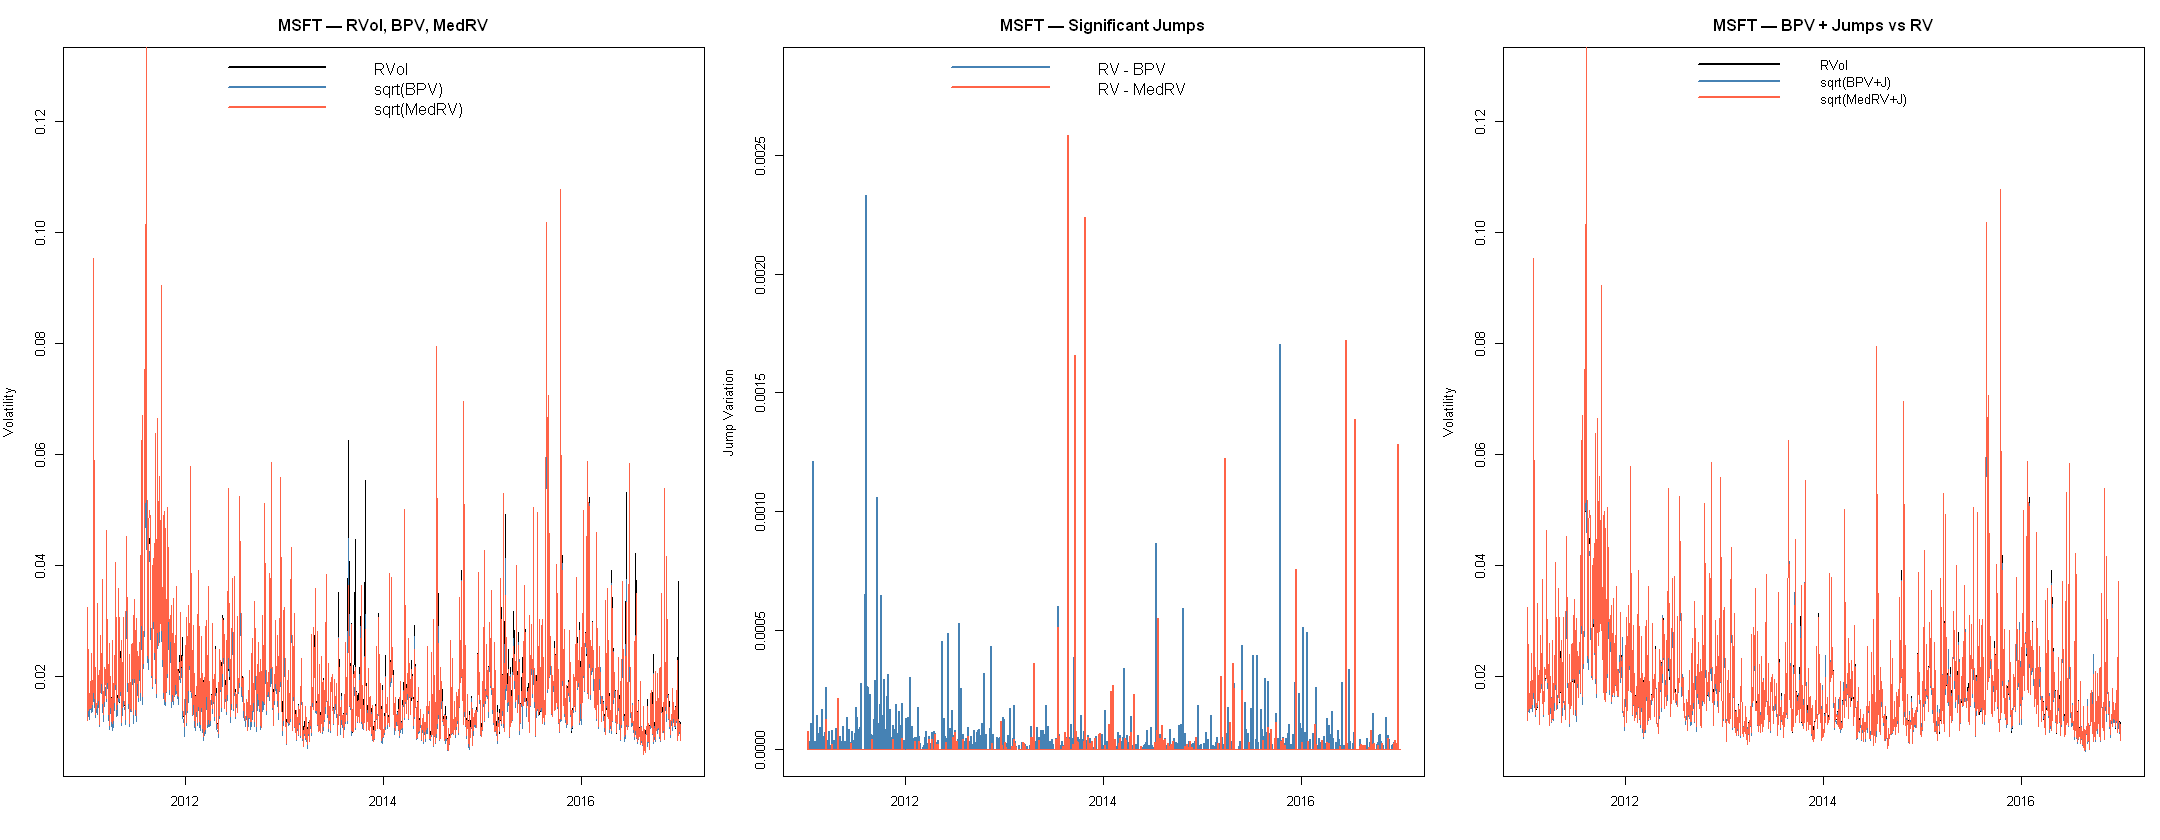


=== XOM — Jump Summary ===
Significant jump days (BPV test)  : 219 / 504 (43.5%)
Significant jump days (MedRV test): 67 / 504 (13.3%)
Mean RV   : 0.000620
Mean BPV  : 0.000519
Mean MedRV: 0.000831


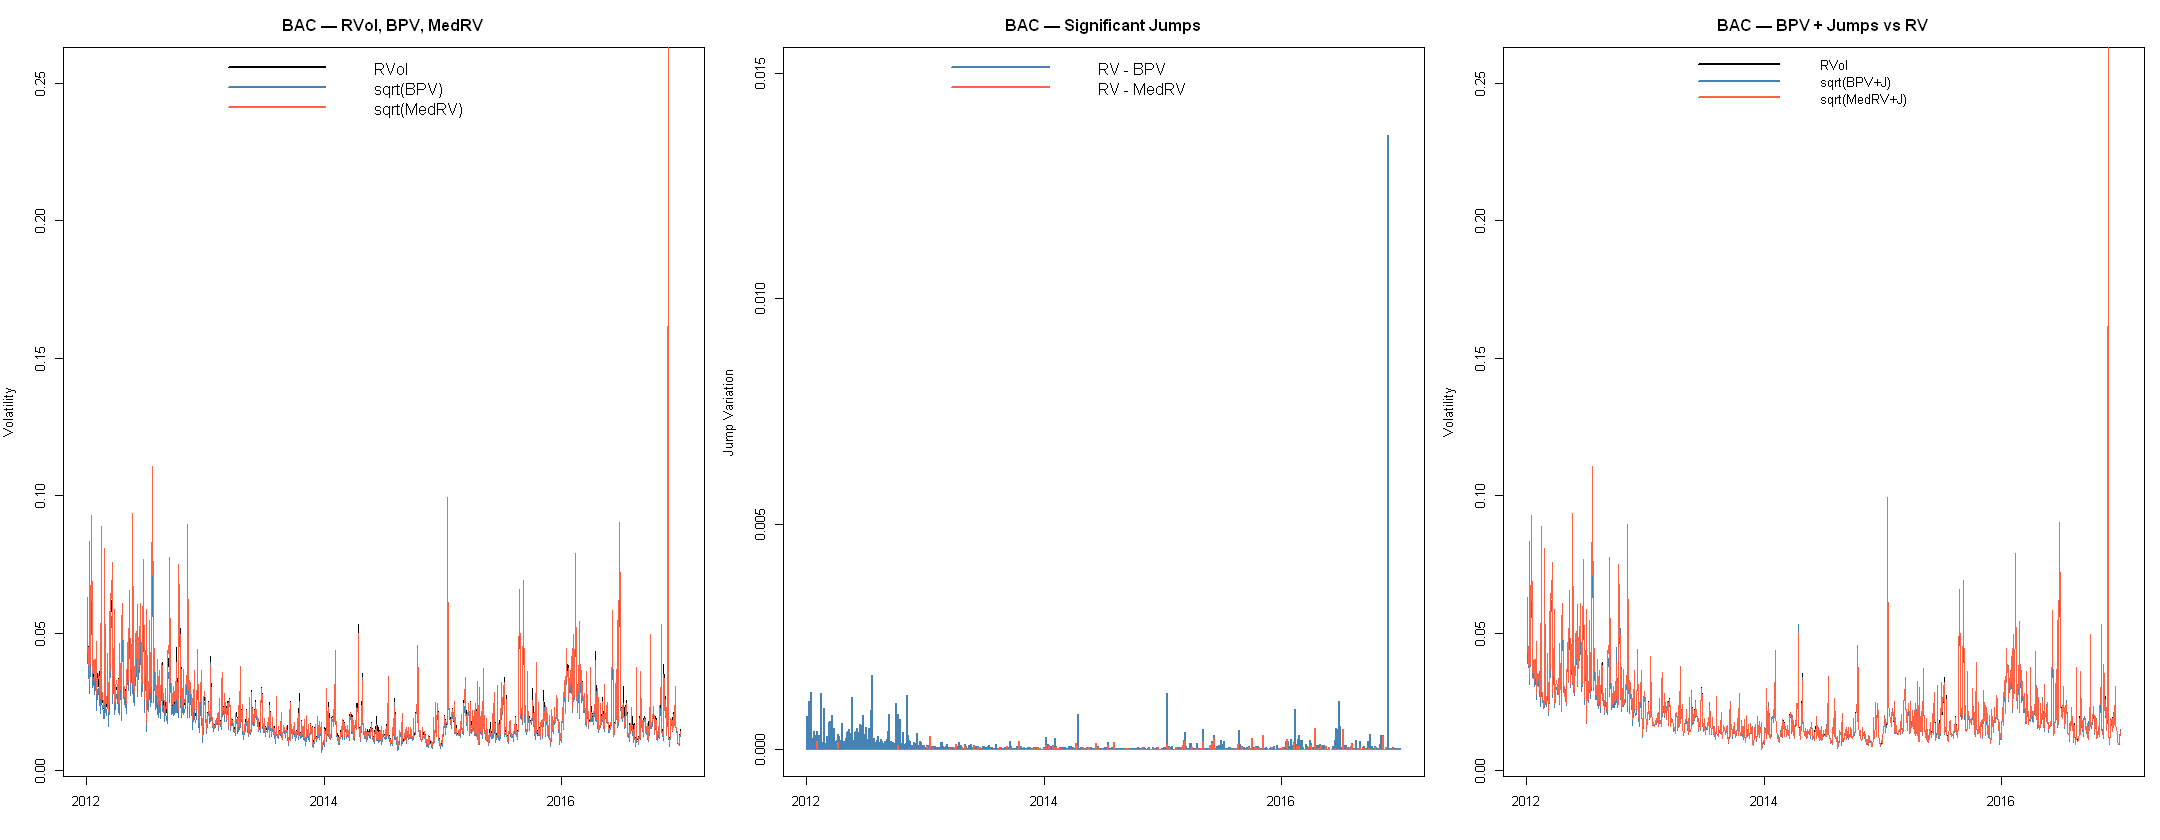

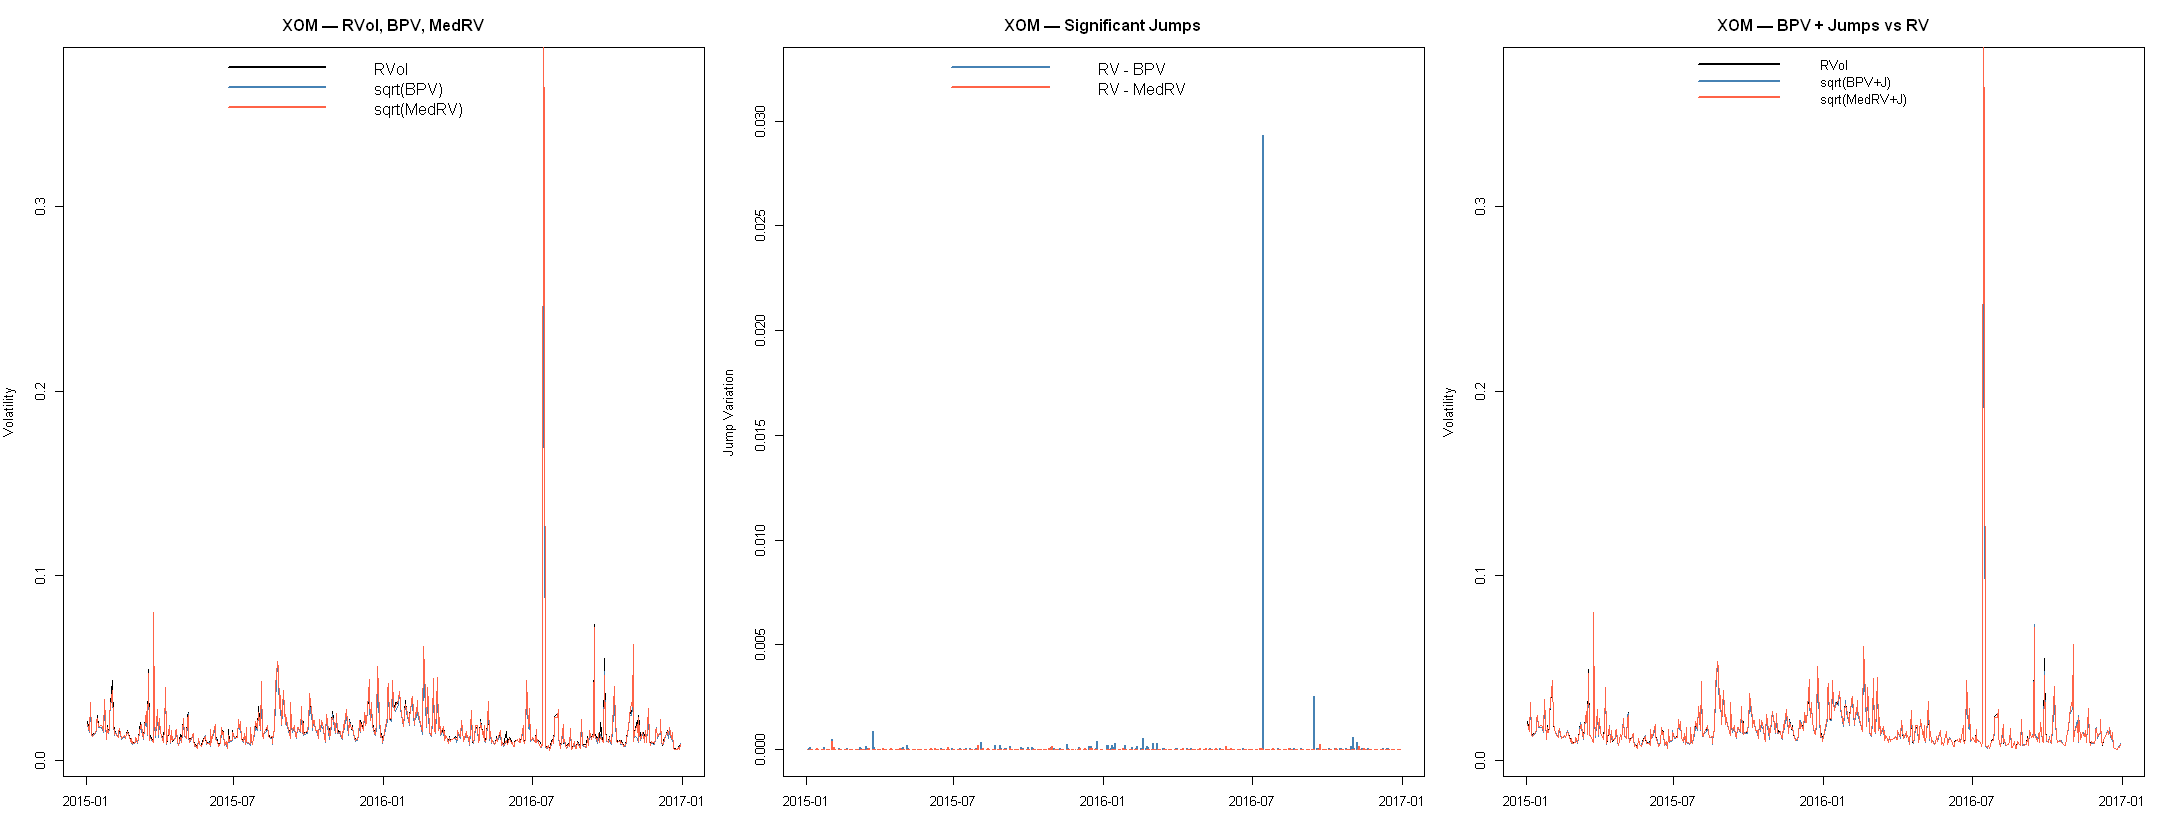

In [65]:
jumps_msft <- compute_jumps(msft_clean, "MSFT", rv_msft)
jumps_bac  <- compute_jumps(bac_clean,  "BAC",  rv_bac)
jumps_xom  <- compute_jumps(xom_clean,  "XOM",  rv_xom)

In [66]:
compare_garch_vs_rv <- function(clean_data, ticker, rv_result) {
  
  # 1. Calculate Daily Returns
  # We sum the 1-minute log returns for each day to get the total daily log return
  daily_returns <- apply.daily(na.omit(clean_data[, "Returns"]), sum)
  index(daily_returns) <- as.Date(index(daily_returns))
  
  # 2. Specify the ARMA(1,1)-GARCH(1,1) Model
  garch_spec <- ugarchspec(
    variance.model = list(model = "sGARCH", garchOrder = c(1, 1)),
    mean.model     = list(armaOrder = c(1, 1), include.mean = TRUE),
    distribution.model = "norm"
  )
  
  # 3. Fit the Model
  # We use solver = "hybrid" because it is much more robust at finding convergence
  garch_fit <- ugarchfit(spec = garch_spec, data = daily_returns, solver = "hybrid")
  
  # 4. Extract Estimated Volatility (sigma)
  # ugarchfit returns conditional standard deviation natively
  garch_vol <- sigma(garch_fit) 
  
  # 5. Get Realized Volatility from your previous results (Square root of RV)
  RVol <- sqrt(rv_result$rv_returns)
  
  # 6. Merge them together to ensure dates align perfectly for the plot and stats
  comparison_data <- merge(RVol, garch_vol, join = "inner")
  colnames(comparison_data) <- c("Realized_Vol", "GARCH_Vol")
  
  # 7. Compute the correlation and Mean Absolute Error (MAE)
  corr_vol <- cor(comparison_data$Realized_Vol, comparison_data$GARCH_Vol, use = "complete.obs")
  mae_vol  <- mean(abs(comparison_data$Realized_Vol - comparison_data$GARCH_Vol), na.rm = TRUE)
  
  # 8. Console Output
  cat(sprintf("\n==================================================\n"))
  cat(sprintf("   %s — ARMA-GARCH(1,1) vs Realized Volatility\n", ticker))
  cat(sprintf("==================================================\n"))
  cat(sprintf("Correlation between GARCH Vol and RVol : %.4f\n", corr_vol))
  cat(sprintf("Mean Absolute Error (MAE)              : %.6f\n", mae_vol))
  
  # 9. Plotting Actual RVol vs GARCH Estimated Volatility
  par(mar = c(4, 4, 3, 2) + 0.1)
  
  # Plot Realized Volatility (Black)
  plot.zoo(comparison_data$Realized_Vol, col = "black", lwd = 1,
           main = paste(ticker, "— GARCH Estimated Vol vs Realized Volatility"),
           ylab = "Volatility", xlab = NA)
           
  # Overlay GARCH Estimated Volatility (Red)
  lines(as.zoo(comparison_data$GARCH_Vol), col = "red", lwd = 1.5)
  
  legend("topright", legend = c("Realized Vol (sqrt(RV))", "GARCH Volatility"),
         col = c("black", "red"), lwd = c(1, 1.5), bty = "n", cex = 1)
  
  par(mfrow = c(1, 1))
  
  # Return the fitted object in case you need to run tests on the residuals later
  return(invisible(list(fit = garch_fit, comparison = comparison_data)))
}


   MSFT — ARMA-GARCH(1,1) vs Realized Volatility
Correlation between GARCH Vol and RVol : 0.2267
Mean Absolute Error (MAE)              : 0.006758

   BAC — ARMA-GARCH(1,1) vs Realized Volatility
Correlation between GARCH Vol and RVol : 0.5149
Mean Absolute Error (MAE)              : 0.006492


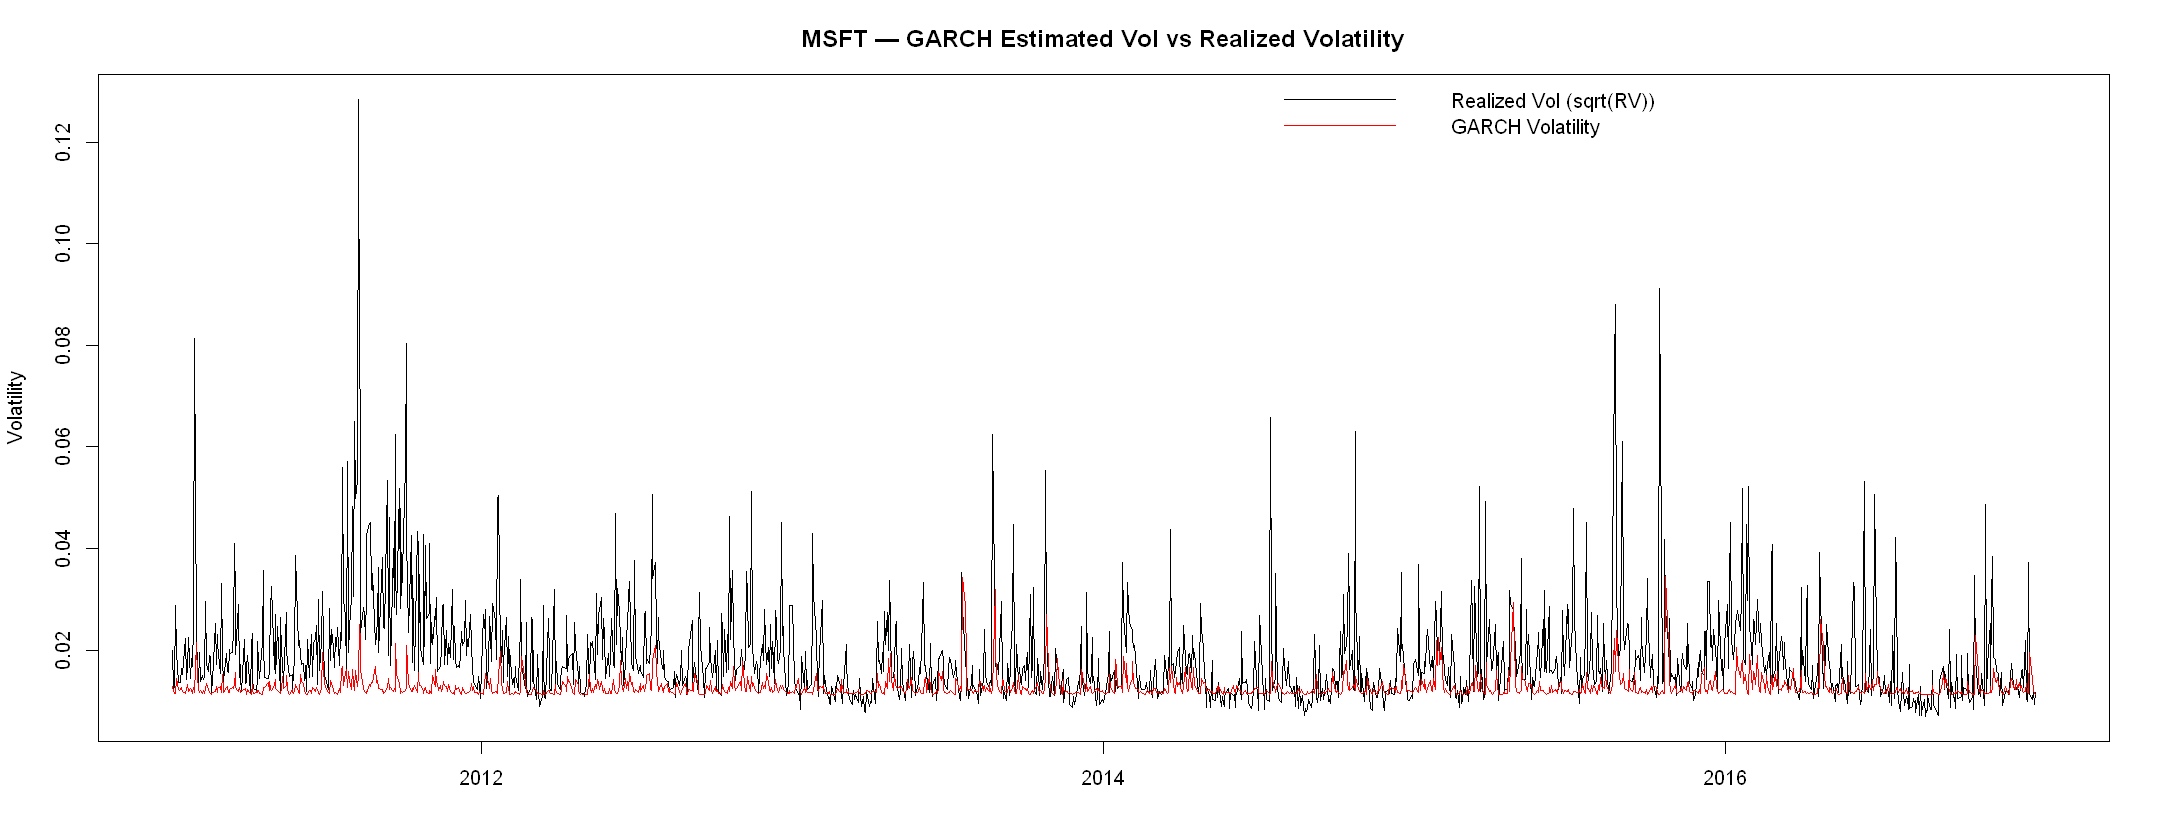


   XOM — ARMA-GARCH(1,1) vs Realized Volatility
Correlation between GARCH Vol and RVol : 0.1699
Mean Absolute Error (MAE)              : 0.006506


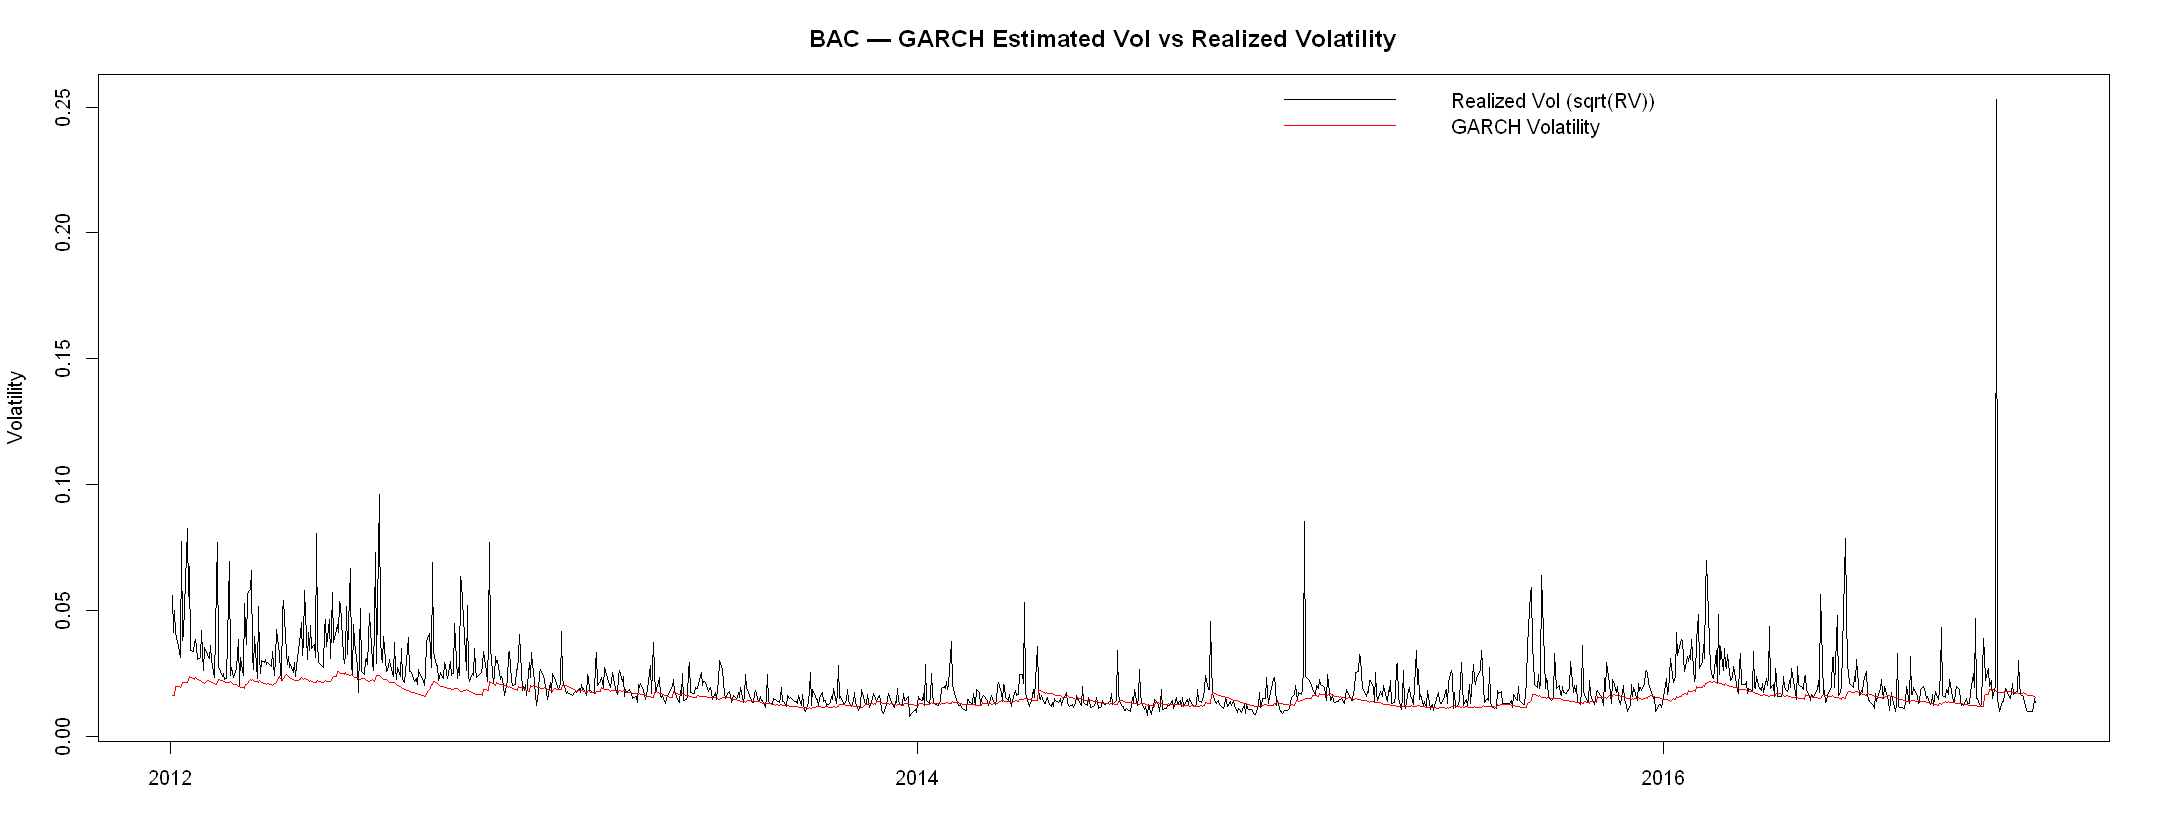

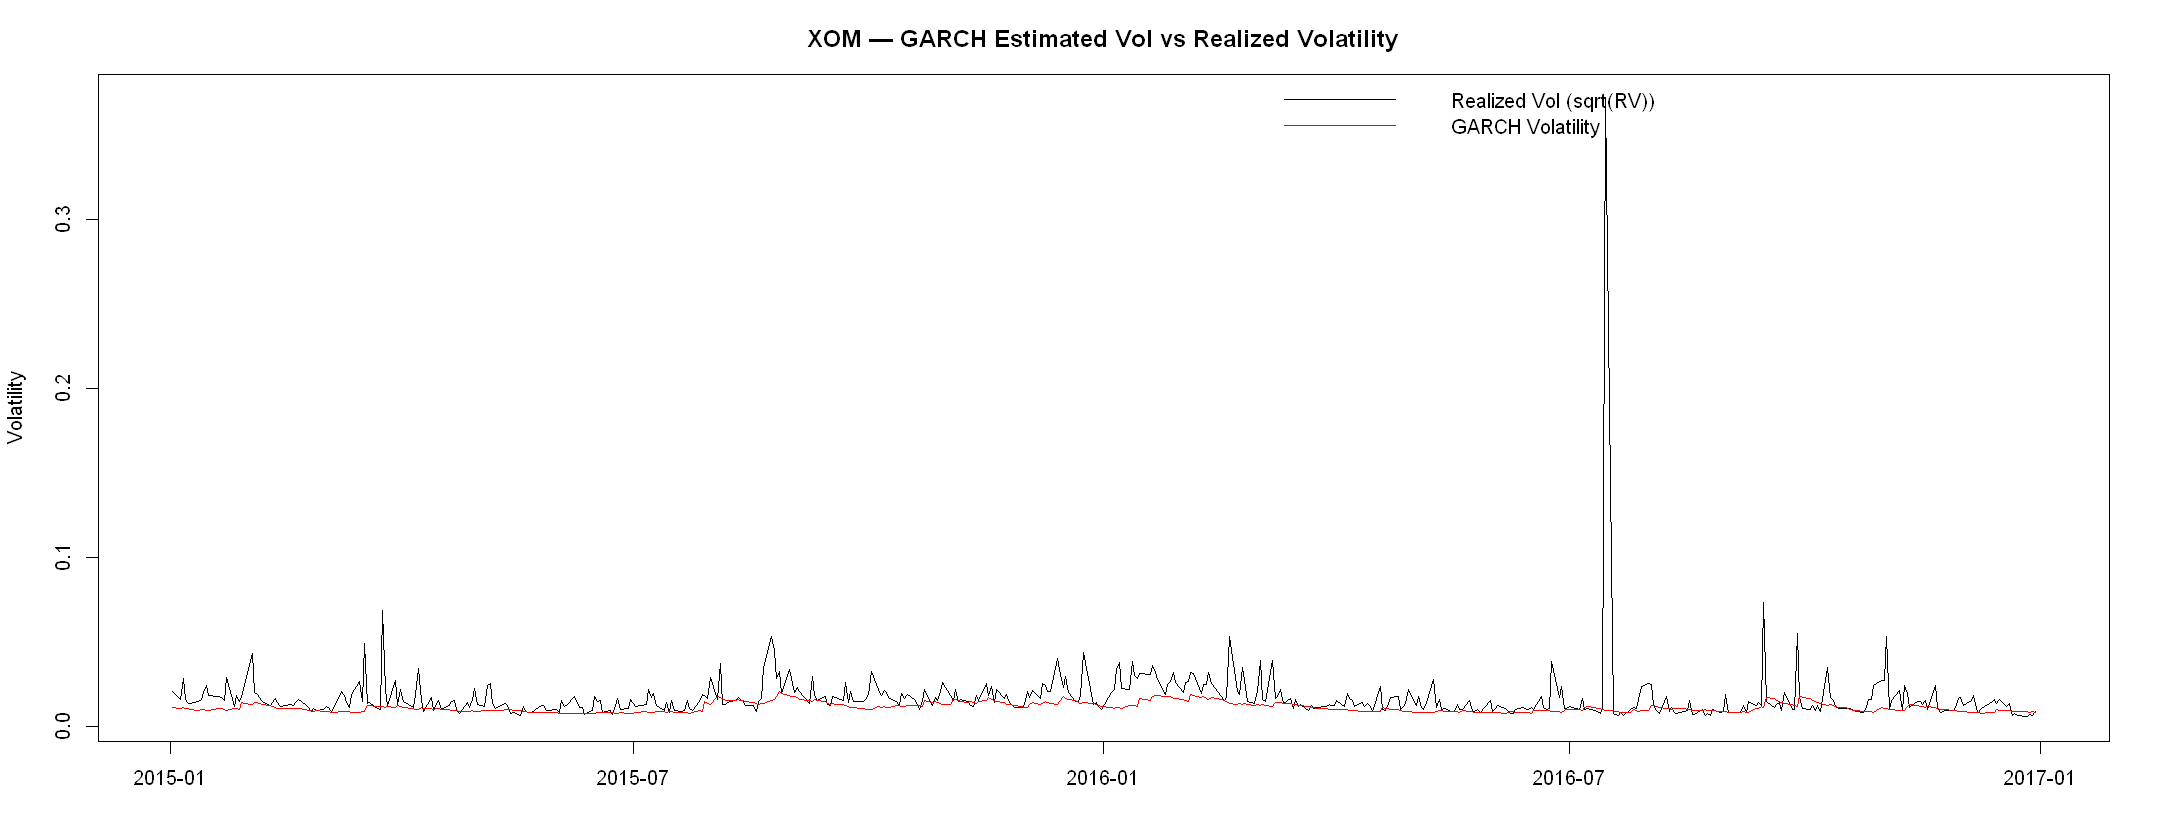

In [67]:
garch_msft <- compare_garch_vs_rv(msft_clean, "MSFT", rv_msft)
garch_bac  <- compare_garch_vs_rv(bac_clean,  "BAC",  rv_bac)
garch_xom  <- compare_garch_vs_rv(xom_clean,  "XOM",  rv_xom)